# Time-Domain Diffuse Optical Tomography (TD-DOT) in un mezzo semi-infinito
### Relazione teorica e di programmazione

Lorenzo Lazzari, 10532056

Questa relazione riprende il progetto originale *DOT Project* (Part 1/2/3,
mezzo **infinito**, sorgente e rivelatore **coincidenti** in $r=0$) e lo
riscrive secondo le **nuove ipotesi** introdotte nel codice più recente del
repository:

1. **Mezzo semi-infinito**: interfaccia piana $z=0$ fra aria e mezzo
   diffondente. Per il mismatch di indice di rifrazione, la fluenza non si
   annulla sull'interfaccia fisica ma su un piano *estrapolato* $z=-z_b$,
   imposto con il **metodo delle immagini**.
2. **Sorgente e rivelatore non coincidenti**: 8 rivelatori disposti a
   raggiera (4 assi cartesiani + 4 bisettrici) a distanza $\rho_{sd}=12$ mm
   dalla sorgente, anziché un'unica coppia sorgente-rivelatore in $r=0$.
3. **Dominio**: sorgente nell'origine $(0,0,0)$; $(x,y)$ simmetrico attorno
   all'origine, $z\ge 0$ nel mezzo.

Il documento segue l'ordine dei tre file del repository (`DOT_Part1_mezzo_semiinfinito.py`,
`DOT_Part2_griglia_spaziotemporale.py`, `DOT_Part2_W_A_M_senza_rumore.py`):
per ogni blocco di codice significativo viene mostrato (a) il codice stesso con
il relativo output grafico eseguito, seguito da (b) una cella di commento con
**teoria/formule analitiche** e **logica di programmazione**.


---
## Parte 1 — Fluenza e contrasto in un mezzo semi-infinito
*(da `DOT_Part1_mezzo_semiinfinito.py`)*


In [1]:
%matplotlib inline
# STEP 1 - Proprieta' ottiche del mezzo (bulk)
import numpy as np
import matplotlib.pyplot as plt
from numpy import exp, pi, sqrt

mu_a0 = 0.01                     # assorbimento di base [mm^-1]
mu_s0 = 1.00                     # scattering ridotto di base [mm^-1]
mu_s  = np.linspace(0.5, 2, 5)         # per lo studio parametrico
mu_a  = np.linspace(0, 0.04, 5)        # per lo studio parametrico
n_idx = 1.4                      # indice di rifrazione relativo (mezzo/aria)

D = 1/(3*mu_s0)                  # coefficiente di diffusione [mm]
v = 300/n_idx                    # velocita' della luce nel mezzo [mm/ns]

Nsample = 1024
t = np.linspace(0.05, 10, Nsample)     # asse dei tempi [ns]


**Teoria.** Le grandezze ottiche di base sono quelle standard
dell'approssimazione di diffusione: $\mu_a$ (assorbimento), $\mu_s'$
(scattering ridotto), il coefficiente di diffusione

$$D=\frac{1}{3\mu_s'}$$

e la velocità della luce nel mezzo $v = c_0/n$ (qui $n=1.4$, un tessuto
biologico tipico, **non** $n=1$ come nell'originale: è proprio questo
mismatch fra indice del mezzo e indice dell'aria a generare, nella Parte
successiva, la necessità della condizione al contorno estrapolata).
Rispetto all'originale (dove sorgente e rivelatore coincidevano, $\rho=0$),
qui viene introdotta anche $\rho_{sd}$ (distanza sorgente-rivelatore), non
più nulla.

**Logica di programmazione.** Nessuna differenza sintattica rispetto
all'originale: `numpy.linspace` genera gli array per lo studio parametrico
di $\mu_s'$ e $\mu_a$; `D` e `v` sono scalari calcolati una volta,
riusati nelle funzioni successive. Non essendoci un grafico associato a
questa cella, non c'è output da commentare: è la sola inizializzazione dei
parametri fisici.


In [2]:
# STEP 2 - Condizione al contorno estrapolata (mezzo semi-infinito)
def A_coefficient(n):
    '''Coefficiente di mismatch A = (1+Reff)/(1-Reff).'''
    Reff = -1.4399/n**2 + 0.7099/n + 0.6681 + 0.0636*n
    return (1 + Reff)/(1 - Reff)

A_coeff = A_coefficient(n_idx)
z0 = 1/mu_s0                     # profondita' di inserzione della sorgente
                                  # (un cammino libero medio di trasporto)
zb = 2*A_coeff*D                 # distanza del piano estrapolato dall'interfaccia

print("="*55)
print("PARAMETRI DEL MEZZO SEMI-INFINITO")
print("="*55)
print(f"Indice di rifrazione relativo n:            {n_idx}")
print(f"Coefficiente di mismatch A:                 {A_coeff:.3f}")
print(f"Profondita' di inserzione sorgente z0:       {z0:.2f} mm")
print(f"Distanza piano estrapolato zb:               {zb:.2f} mm")
print(f"Piano estrapolato a z = -{zb:.2f} mm")
print("="*55 + "\n")

r_s0 = np.array([0.0, 0.0, z0])             # sorgente reale
r_si = np.array([0.0, 0.0, -z0 - 2*zb])     # sorgente immagine


PARAMETRI DEL MEZZO SEMI-INFINITO
Indice di rifrazione relativo n:            1.4
Coefficiente di mismatch A:                 3.251
Profondita' di inserzione sorgente z0:       1.00 mm
Distanza piano estrapolato zb:               2.17 mm
Piano estrapolato a z = -2.17 mm



**Teoria.** Nel mezzo infinito la fluenza puntiforme è nota
analiticamente ovunque; nel mezzo semi-infinito va invece imposta una
condizione al contorno sull'interfaccia $z=0$. A causa del mismatch di
indice di rifrazione (parte dei fotoni diffusi viene riflessa internamente
invece di uscire), la fluenza non si annulla sul piano fisico ma su un piano
**estrapolato** $z=-z_b$ (Haskell *et al.*, 1994; Patterson *et al.*, 1989):

$$
R_{\rm eff}(n) = -\frac{1.4399}{n^2}+\frac{0.7099}{n}+0.6681+0.0636\,n ,
\qquad
A(n)=\frac{1+R_{\rm eff}}{1-R_{\rm eff}}, \qquad
z_b = 2\,A\,D .
$$

Per $n=1$ (nessun mismatch) si avrebbe $R_{\rm eff}=0$, $A=1$, $z_b=2D$: il
caso limite "trasparente" (il caso dell'originale). Con $n=1.4$ i fotoni sono
parzialmente intrappolati ($A>1$), quindi $z_b$ si allontana dall'interfaccia.
La condizione $\phi(z=-z_b)=0$ si impone **senza** risolvere una nuova
equazione, con il **metodo delle immagini**: si sovrappone alla sorgente
reale (inserita a profondità $z_0=1/\mu_s'$, un cammino libero medio di
trasporto sotto la superficie) una sorgente immagine di segno opposto,
speculare rispetto al piano estrapolato:

$$
r_{s0}=(0,0,z_0), \qquad r_{si}=(0,0,-z_0-2z_b).
$$

Essendo l'equazione di diffusione lineare, la differenza delle due fluenze
puntiformi (Parte 1, Step 4) si annulla identicamente sul piano equidistante
dalle due sorgenti, cioè $z=-z_b$, per costruzione geometrica.

**Logica di programmazione.** `A_coefficient(n)` implementa direttamente la
formula del fit empirico; è scritta per essere generica in `n` (funziona
anche se richiamata con un array, anche se qui viene passato uno scalare).
`z0` e `zb` sono poi riusati per costruire i vettori posizione 3D
`r_s0`/`r_si` con `numpy.array`. I `print` con f-string producono un
riepilogo leggibile dei parametri geometrici derivati, utile per verificare
a colpo d'occhio l'ordine di grandezza (qui $z_0\simeq 1$ mm, $z_b\simeq
2.2$ mm): nessun grafico in questa cella, solo output testuale.


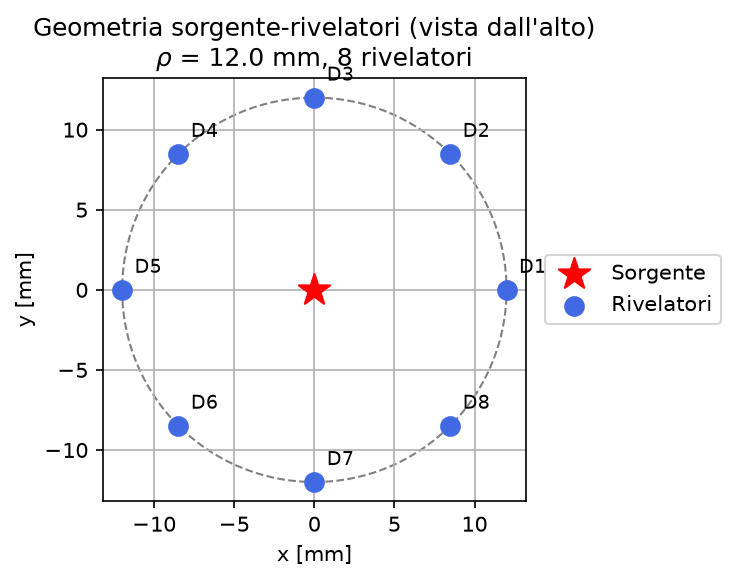

In [3]:
# STEP 3 - Geometria sorgente-rivelatori
rho_sd = 12.0                    # mm, distanza sorgente-rivelatore
angoli = np.arange(0, 360, 45)   # 8 direzioni
det_xy = np.array([[rho_sd*np.cos(np.radians(a)),
                     rho_sd*np.sin(np.radians(a))] for a in angoli])
N_det = det_xy.shape[0]

r_d0 = np.column_stack((det_xy, np.full(N_det, z0)))
r_di = np.column_stack((det_xy, np.full(N_det, -z0 - 2*zb)))

plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(0, 0, marker='*', s=250, c='red', label='Sorgente', zorder=3)
ax.scatter(det_xy[:, 0], det_xy[:, 1], marker='o', s=80, c='royalblue',
           label='Rivelatori', zorder=3)
for i, (x, y) in enumerate(det_xy):
    ax.annotate(f'D{i+1}', (x, y), textcoords='offset points',
                xytext=(6, 6), ha='left', va='bottom', fontsize=9)
circle = plt.Circle((0, 0), rho_sd, fill=False, linestyle='--', color='gray')
ax.add_patch(circle)
ax.set_aspect('equal')
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
ax.set_title(f"Geometria sorgente-rivelatori (vista dall'alto)\n"
             f"$\\rho$ = {rho_sd} mm, {N_det} rivelatori")
ax.grid()
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()


**Teoria.** La sorgente resta nell'origine $(0,0,0)$; gli 8
rivelatori sono disposti su una circonferenza di raggio $\rho_{sd}=12$ mm,
ogni $45^\circ$ (4 lungo gli assi cartesiani, 4 lungo le bisettrici):

$$
x_k = \rho_{sd}\cos(k\cdot 45^\circ), \qquad
y_k = \rho_{sd}\sin(k\cdot 45^\circ), \qquad k=0,\dots,7 .
$$

Per reciprocità (la sorgente vede il rivelatore come il rivelatore vede la
sorgente), anche ogni rivelatore viene trattato con lo stesso metodo delle
immagini della sorgente: è inserito alla stessa profondità $z_0$ sotto la
sua posizione $(x_k,y_k)$, con un'immagine speculare a $-z_0-2z_b$. Questa è
la differenza geometrica principale rispetto all'originale: la fluenza e il
contrasto andranno ora valutati per ciascuna delle 8 coppie sorgente-
rivelatore, non più in un unico punto $r=0$.

**Logica di programmazione.** `angoli` è generato con `np.arange(0,360,45)`
(8 valori); la lista di comprensione calcola $(x_k,y_k)$ per ciascun angolo
e viene impacchettata in un array $(8,2)$. `np.column_stack` affianca la
coordinata $z$ costante ($z_0$ o $-z_0-2z_b$) alle coordinate $(x,y)$ di
ciascun rivelatore, producendo `r_d0`/`r_di` come array $(8,3)$: una riga
per rivelatore. Nel grafico, `plt.Circle` disegna la circonferenza guida,
`ax.annotate` etichetta ogni rivelatore (D1...D8), `bbox_to_anchor` sposta
la legenda fuori dagli assi per non coprire i punti.

**Commento al grafico.** Gli 8 rivelatori risultano equidistanti dalla
sorgente (tutti sulla circonferenza tratteggiata) e coprono uniformemente le
8 direzioni: D1, D3, D5, D7 sui quattro assi cartesiani, D2, D4, D6, D8 sulle
bisettrici. È questa disposizione a raggiera, assente nell'originale (dove
$\rho_{sd}=0$), che fornirà l'informazione spaziale sfruttata nella
ricostruzione tomografica.


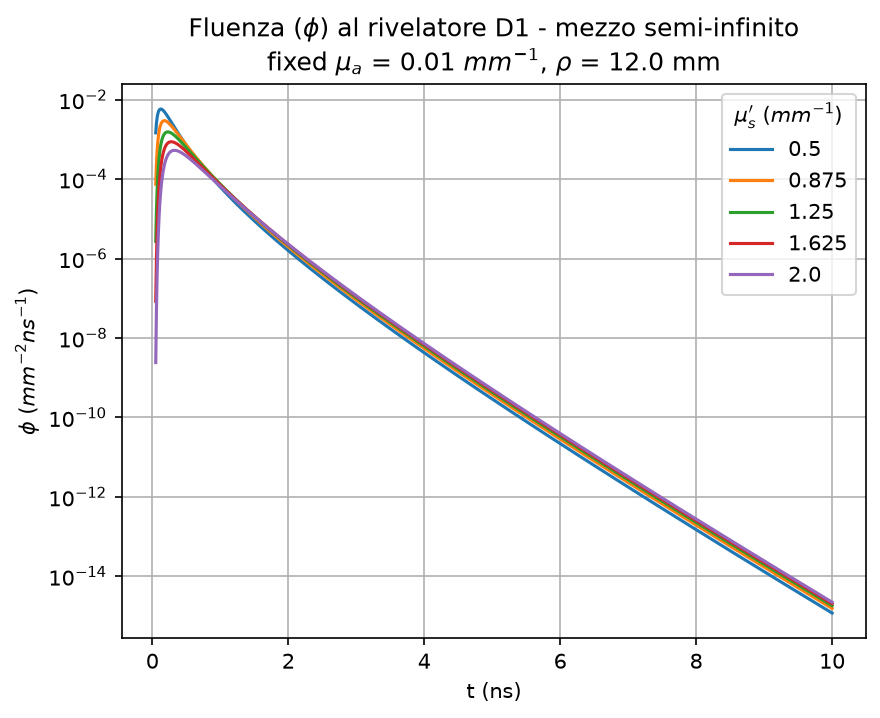

In [4]:
# STEP 4 - Fluenza omogenea: mezzo infinito (funzione base) e
#          mezzo semi-infinito (metodo delle immagini)
def fluence_inf(mu_a0, mu_s0, n, t, r):
    '''Fluenza in un mezzo infinito omogeneo, sorgente impulsiva in r=0.'''
    D = 1/(3*mu_s0)
    v = 300/n
    return (v/(4*pi*D*v*t)**1.5) * exp(-(r**2)/(4*D*v*t) - mu_a0*v*t)

def fluence_semiinf(mu_a0, mu_s0, n, t, r_field, r_sorg, r_imm):
    '''Fluenza nel mezzo semi-infinito nel punto r_field, dovuta ad una
    sorgente reale in r_sorg e alla sua immagine in r_imm (sottratta).'''
    r_reale = np.linalg.norm(np.asarray(r_field) - np.asarray(r_sorg))
    r_immag = np.linalg.norm(np.asarray(r_field) - np.asarray(r_imm))
    return fluence_inf(mu_a0, mu_s0, n, t, r_reale) - \
           fluence_inf(mu_a0, mu_s0, n, t, r_immag)

# Rivelatore di riferimento per gli studi parametrici: D1 (asse x, y=0)
rd_ref = r_d0[0]

# --- fluenza al rivelatore D1, al variare di mu_s (mu_a0 fissato) ---
plt.figure()
for i in range(5):
    Di = 1/(3*mu_s[i]); z0_i = 1/mu_s[i]; zb_i = 2*A_coeff*Di
    rs_i = np.array([0, 0, z0_i])
    ri_i = np.array([0, 0, -z0_i - 2*zb_i])
    rd_i = np.array([rho_sd, 0, z0_i])
    y = fluence_semiinf(mu_a0, mu_s[i], n_idx, t, rd_i, rs_i, ri_i)
    plt.semilogy(t, y)
plt.title(f"Fluenza ($\\phi$) al rivelatore D1 - mezzo semi-infinito\n"
          f"fixed $\\mu_a$ = {mu_a0} $mm^{{-1}}$, $\\rho$ = {rho_sd} mm")
plt.xlabel('t (ns)'); plt.ylabel('$\\phi$ ($mm^{-2}ns^{-1}$)')
plt.legend(np.round(mu_s, 3), title="$\\mu_s'$ ($mm^{-1}$)")
plt.grid(); plt.show()


**Teoria.** La fluenza in un mezzo infinito omogeneo per una
sorgente impulsiva isotropa (soluzione elementare dell'equazione di
diffusione) è

$$
\phi_\infty(\vec r,t)=\frac{v}{(4\pi D v t)^{3/2}}
\exp\!\Big(-\frac{r^2}{4Dvt}-\mu_a v t\Big),
$$

identica alla formula usata nell'originale, ma qui **non più valutata in
$r=0$**: $r$ è ora la distanza generica fra un punto qualsiasi e la
sorgente (o la sua immagine). La fluenza nel mezzo semi-infinito si ottiene
per sovrapposizione lineare (metodo delle immagini, Step 2):

$$
\phi_{\rm semiinf}(\vec r,t)=\phi_\infty(|\vec r-\vec r_{s0}|,t)
-\phi_\infty(|\vec r-\vec r_{si}|,t).
$$

Nel primo grafico si varia $\mu_s'$ a $\mu_a$ fissato, misurando al
rivelatore D1 ($\rho_{sd}=12$ mm dalla sorgente, non più coincidente con
essa).

**Logica di programmazione.** `fluence_inf` è identica, nella struttura, a
quella dell'originale (stessa formula, stesso ordine argomenti). `fluence_semiinf`
la richiama due volte (sorgente reale e immagine) e ne fa la differenza,
usando `np.linalg.norm` per calcolare le distanze euclidee da vettori 3D
generici, invece dello scalare `r` dell'originale. **Punto delicato**: dato
che $z_0$ e $z_b$ dipendono da $\mu_s'$ (tramite $D=1/(3\mu_s')$ e $z_0=1/\mu_s'$),
al variare di $\mu_s'$ nel ciclo va ricalcolata *tutta* la geometria
(sorgente reale/immagine, posizione del rivelatore reale) — non si possono
riusare `r_s0`, `r_si`, `rd_ref` fissati fuori dal ciclo come nello Step 3.

**Commento al grafico.** Come nell'originale, $\mu_a$ governa la pendenza
del decadimento in coda (retta in scala log), mentre $\mu_s'$ sposta
soprattutto l'istante e l'ampiezza del picco. La differenza rispetto
all'originale è che le curve partono da un valore molto più basso e
mostrano una salita iniziale, poiché il fotone impiega un tempo finito per
diffondere dalla sorgente al rivelatore (qui a 12 mm, non più a distanza
nulla).


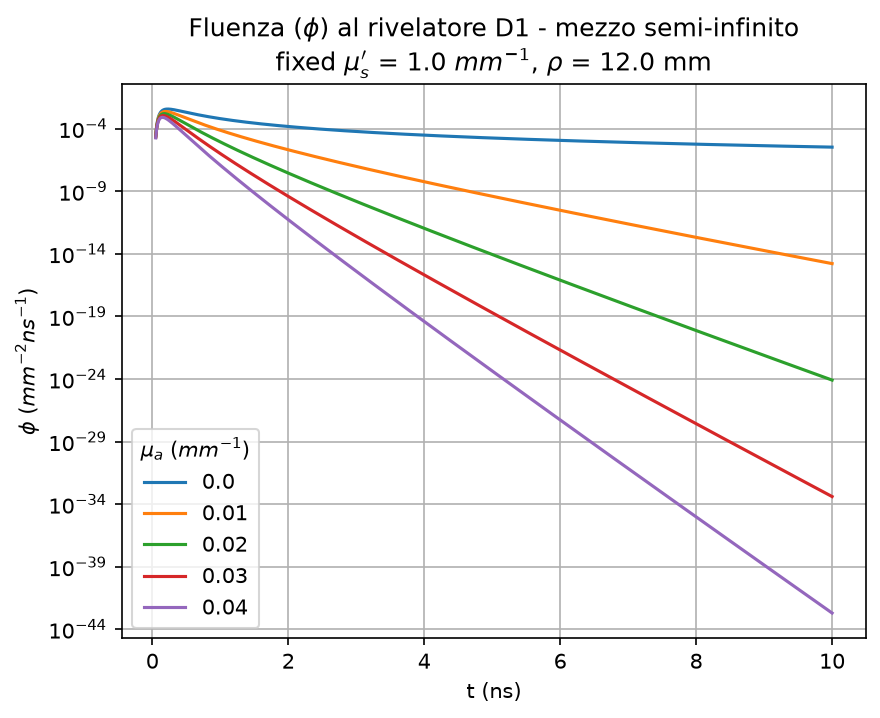

In [5]:
# --- fluenza al rivelatore D1, al variare di mu_a (mu_s0 fissato) ---
plt.figure()
for i in range(5):
    y = fluence_semiinf(mu_a[i], mu_s0, n_idx, t, rd_ref, r_s0, r_si)
    plt.semilogy(t, y)
plt.title(f"Fluenza ($\\phi$) al rivelatore D1 - mezzo semi-infinito\n"
          f"fixed $\\mu_s'$ = {mu_s0} $mm^{{-1}}$, $\\rho$ = {rho_sd} mm")
plt.xlabel('t (ns)'); plt.ylabel('$\\phi$ ($mm^{-2}ns^{-1}$)')
plt.legend(mu_a, title='$\\mu_a$ ($mm^{-1}$)')
plt.grid(); plt.show()


**Teoria.** Qui si varia $\mu_a$ a $\mu_s'$ fissato: poiché $z_0$ e
$z_b$ dipendono **solo** da $\mu_s'$ (non da $\mu_a$), la geometria
sorgente/rivelatore reale-immagine resta la stessa dello Step 2/3 per
tutte le curve, e cambia solo il fattore di assorbimento $\exp(-\mu_a v t)$
dentro `fluence_inf`.

**Logica di programmazione.** Per questo motivo il ciclo può riusare
direttamente `rd_ref`, `r_s0`, `r_si` calcolati una sola volta fuori dal
ciclo (a differenza della cella precedente), rendendo il codice più
semplice: è un esempio diretto di come la struttura del problema fisico
(quali grandezze dipendono da quale parametro) si rifletta nella struttura
del codice (cosa va ricalcolato dentro vs. fuori dal ciclo).

**Commento al grafico.** Il comportamento qualitativo è identico
all'originale: $\mu_a$ fissa la pendenza della coda esponenziale (in scala
log, rette parallele traslate); la curva $\mu_a=0$ (nessun assorbimento) è
l'inviluppo superiore, poiché ogni assorbimento aggiuntivo riduce
monotonicamente la fluenza a parità di tempo.


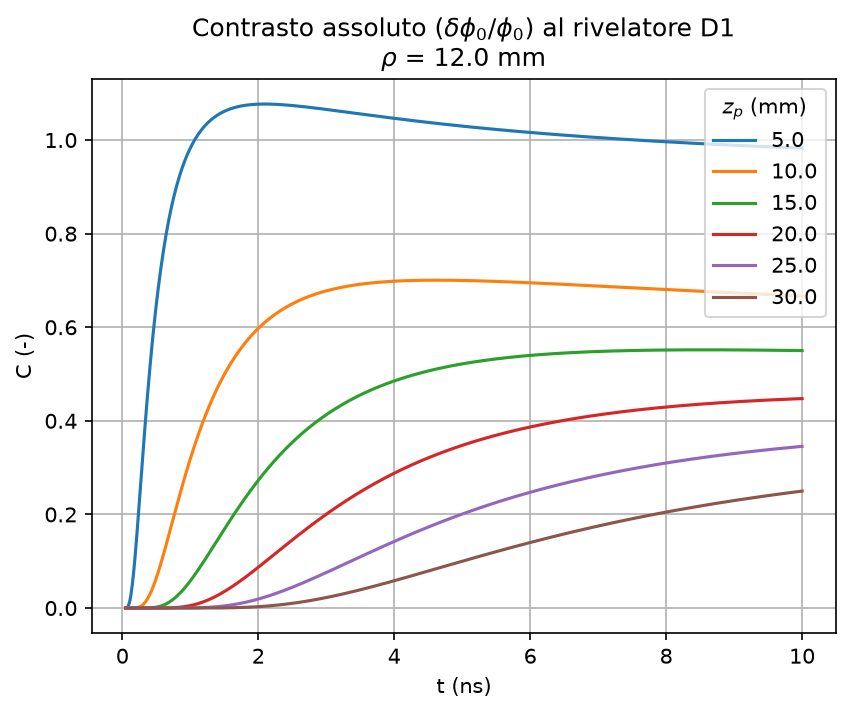

In [6]:
# STEP 5 - Contrasto: variazione della fluenza dovuta ad una
#          inclusione assorbente (approssimazione di Born)
def deltaphi_inf(mu_a0, mu_s0, n, t, dmu_a, V, r, r1):
    D = 1/(3*mu_s0); v = 300/n
    return -(v**2)/((4*pi*D*v)**2.5 * t**1.5) * exp(-mu_a0*v*t) * \
            dmu_a*V*(1/r + 1/r1)*exp(-(r+r1)**2/(4*D*v*t))

def deltaphi_semiinf(mu_a0, mu_s0, n, t, dmu_a, V, rp, rs, rsi, rd, rdi):
    rp = np.asarray(rp)
    r_s, r_si_ = np.linalg.norm(rp-rs), np.linalg.norm(rp-rsi)
    r_d, r_di_ = np.linalg.norm(rp-rd), np.linalg.norm(rp-rdi)
    t1 = deltaphi_inf(mu_a0, mu_s0, n, t, dmu_a, V, r_s,  r_d)
    t2 = deltaphi_inf(mu_a0, mu_s0, n, t, dmu_a, V, r_s,  r_di_)
    t3 = deltaphi_inf(mu_a0, mu_s0, n, t, dmu_a, V, r_si_, r_d)
    t4 = deltaphi_inf(mu_a0, mu_s0, n, t, dmu_a, V, r_si_, r_di_)
    return t1 - t2 - t3 + t4

dmu_a = 0.01      # variazione di assorbimento dell'inclusione [mm^-1]
V_incl = 1000.0   # volume dell'inclusione [mm^3]

# --- Contrasto in tempo al rivelatore D1, al variare della profondita' zp ---
zp_values = np.linspace(5, 30, 6)
plt.figure()
for zp in zp_values:
    rp = np.array([0, 0, zp])
    dphi = deltaphi_semiinf(mu_a0, mu_s0, n_idx, t, dmu_a, V_incl,
                             rp, r_s0, r_si, rd_ref, r_di[0])
    phi0 = fluence_semiinf(mu_a0, mu_s0, n_idx, t, rd_ref, r_s0, r_si)
    Contrast = np.abs(dphi/phi0)
    plt.plot(t, Contrast)
plt.xlabel('t (ns)'); plt.ylabel('C (-)')
plt.title(f"Contrasto assoluto ($\\delta\\phi_0/\\phi_0$) al rivelatore D1\n"
          f"$\\rho$ = {rho_sd} mm")
plt.legend(np.round(zp_values, 1), title='$z_p$ (mm)', loc=1)
plt.grid(); plt.show()


**Teoria.** Il contrasto è definito come $C=\delta\phi_0/\phi_0$,
dove $\delta\phi_0$ è la perturbazione di fluenza dovuta a una piccola
inclusione assorbente $\delta\mu_a$ di volume $V$ in posizione $\vec r_p$.
Nel mezzo **infinito** (approssimazione di Born al prim'ordine, come
nell'originale ma qui con $r\ne r_1$ generici, non più $r=r_1$):

$$
\delta\phi_0(\vec r,\vec r_1,t)= -\frac{v^2}{(4\pi Dv)^{5/2}\,t^{3/2}}\,
\delta\mu_a\,V\Big(\frac1r+\frac1{r_1}\Big)
\exp\!\Big(-\mu_a v t-\frac{(r+r_1)^2}{4Dvt}\Big),
$$

con $r$ = distanza sorgente-voxel e $r_1$ = distanza voxel-rivelatore. Nel
mezzo **semi-infinito**, sia la sorgente sia il rivelatore vanno sostituiti
dalla coppia reale+immagine: essendo $\delta\phi_0$ bilineare nei due
propagatori (sorgente$\to$voxel e voxel$\to$rivelatore), la perturbazione
totale si sviluppa in **4 termini**:

$$
\delta\phi_{\rm semiinf}= \delta\phi_0(r_{sv},r_{vd})
-\delta\phi_0(r_{sv},r_{vd_i})-\delta\phi_0(r_{si_v},r_{vd})
+\delta\phi_0(r_{si_v},r_{vd_i}).
$$

I segni alternati $(+,-,-,+)$ derivano dal fatto che ciascun propagatore
"reale meno immagine" compare due volte nel prodotto, e i segni si
moltiplicano: $(+,-)\times(+,-)=(+,-,-,+)$. Il contrasto resta
$C=|\delta\phi_{\rm semiinf}/\phi_{\rm semiinf}|$, ma sia numeratore sia
denominatore usano ora le formule del mezzo semi-infinito.

**Logica di programmazione.** `deltaphi_inf` è la formula a due immagini
elementare (analoga a `deltafluence` dell'originale, ma con $r\ne r_1$
generici). `deltaphi_semiinf` calcola le 4 distanze punto-sorgente/immagine
e punto-rivelatore/immagine con `np.linalg.norm`, poi combina le 4
chiamate a `deltaphi_inf` con i segni corretti. Il ciclo su `zp_values`
ricalcola per ciascuna profondità sia $\delta\phi$ sia $\phi_0$ (al
denominatore) usando sempre la stessa coppia sorgente/rivelatore D1.

**Commento al grafico.** Come nell'originale, il contrasto è tanto
maggiore (e satura più rapidamente nel tempo) quanto più l'inclusione è
superficiale (zp piccolo): un'inclusione vicina al cammino sorgente-
rivelatore intercetta una frazione maggiore dei fotoni diffusi. Il bordo
estrapolato non cambia questa tendenza qualitativa, ma modifica lievemente
i valori assoluti rispetto al mezzo infinito, soprattutto per profondità
elevate (dove il peso relativo della sorgente immagine è più rilevante).


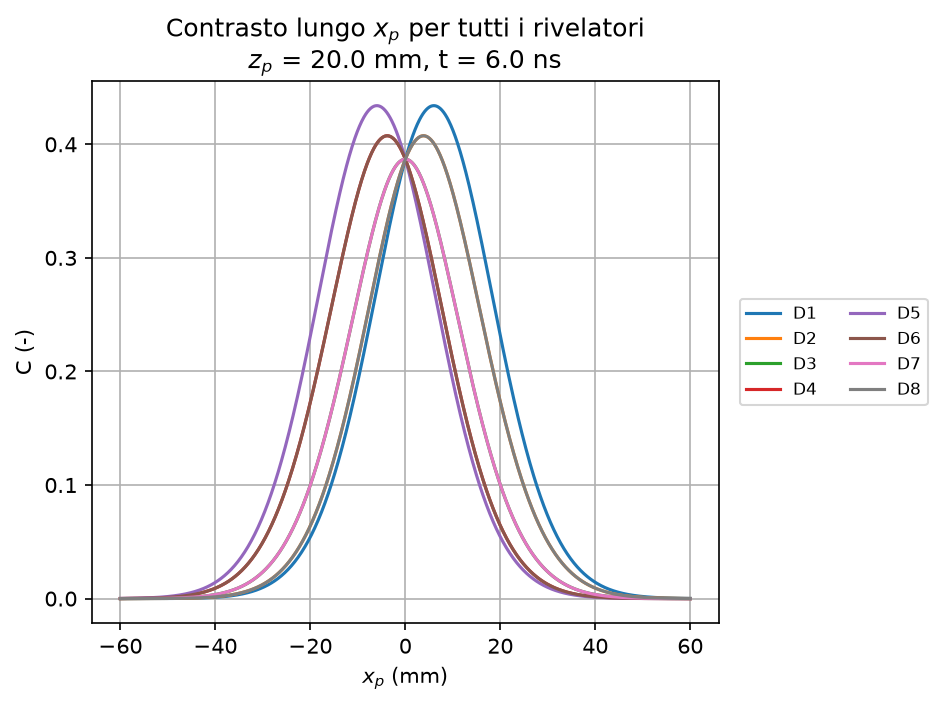

In [7]:
# --- Contrasto lungo x_p, confrontando TUTTI E 8 i rivelatori (t, zp fissati) ---
xp_arr = np.linspace(-60, 60, Nsample)
zp_fix = 20.0
t_fix = 6.0
plt.figure()
for d in range(N_det):
    C = np.zeros_like(xp_arr)
    for k, xp in enumerate(xp_arr):
        rp = np.array([xp, 0, zp_fix])
        dphi = deltaphi_semiinf(mu_a0, mu_s0, n_idx, t_fix, dmu_a, V_incl,
                                 rp, r_s0, r_si, r_d0[d], r_di[d])
        phi0 = fluence_semiinf(mu_a0, mu_s0, n_idx, t_fix, r_d0[d], r_s0, r_si)
        C[k] = abs(dphi/phi0)
    plt.plot(xp_arr, C, label=f'D{d+1}')
plt.xlabel('$x_p$ (mm)'); plt.ylabel('C (-)')
plt.title(f"Contrasto lungo $x_p$ per tutti i rivelatori\n"
          f"$z_p$ = {zp_fix} mm, t = {t_fix} ns")
plt.legend(ncol=2, fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.grid(); plt.tight_layout(); plt.show()


**Teoria.** Qui l'inclusione si muove lungo $x_p$ (a $y_p=0$,
$z_p=20$ mm fissati) ed **esce dall'asse di simmetria** sorgente-rivelatore
per 7 degli 8 rivelatori: solo D1 (a $y=0$, sull'asse $x$) resta allineato
con la traiettoria dell'inclusione per costruzione. È il primo grafico che
non ha un analogo diretto nell'originale, dove con $\rho_{sd}=0$ tutti i
rivelatori (essendocene uno solo, coincidente con la sorgente) misuravano
per definizione lo stesso segnale a parità di $(x_p,y_p,z_p)$.

**Logica di programmazione.** Doppio ciclo esplicito: il ciclo esterno
scorre sugli 8 rivelatori (`r_d0[d]`, `r_di[d]`), quello interno sui punti
della griglia $x_p$; per ciascuna combinazione si richiama
`deltaphi_semiinf`/`fluence_semiinf` puntualmente. Non è vettorizzato (a
differenza di quanto si farà più avanti nella costruzione della matrice
$W$): con $N_{\rm sample}=1024$ punti $\times$ 8 rivelatori il costo resta
comunque modesto. La legenda con `ncol=2` e `bbox_to_anchor` evita che 8
etichette sovraccarichino il grafico.

**Commento al grafico.** I rivelatori vicini alla traiettoria dell'inclusione
(in primis D1, esattamente allineato) mostrano un contrasto molto più alto
rispetto a quelli opposti o perpendicolari (es. D5, sull'asse $-x$, o D3/D7
sull'asse $y$): è proprio questa **diversità di risposta fra rivelatori**,
del tutto assente nell'originale a geometria degenere, a contenere
l'informazione spaziale (l'ampiezza relativa del segnale fra rivelatori
"punta" verso la posizione dell'inclusione) che sarà sfruttata nella
ricostruzione tomografica.


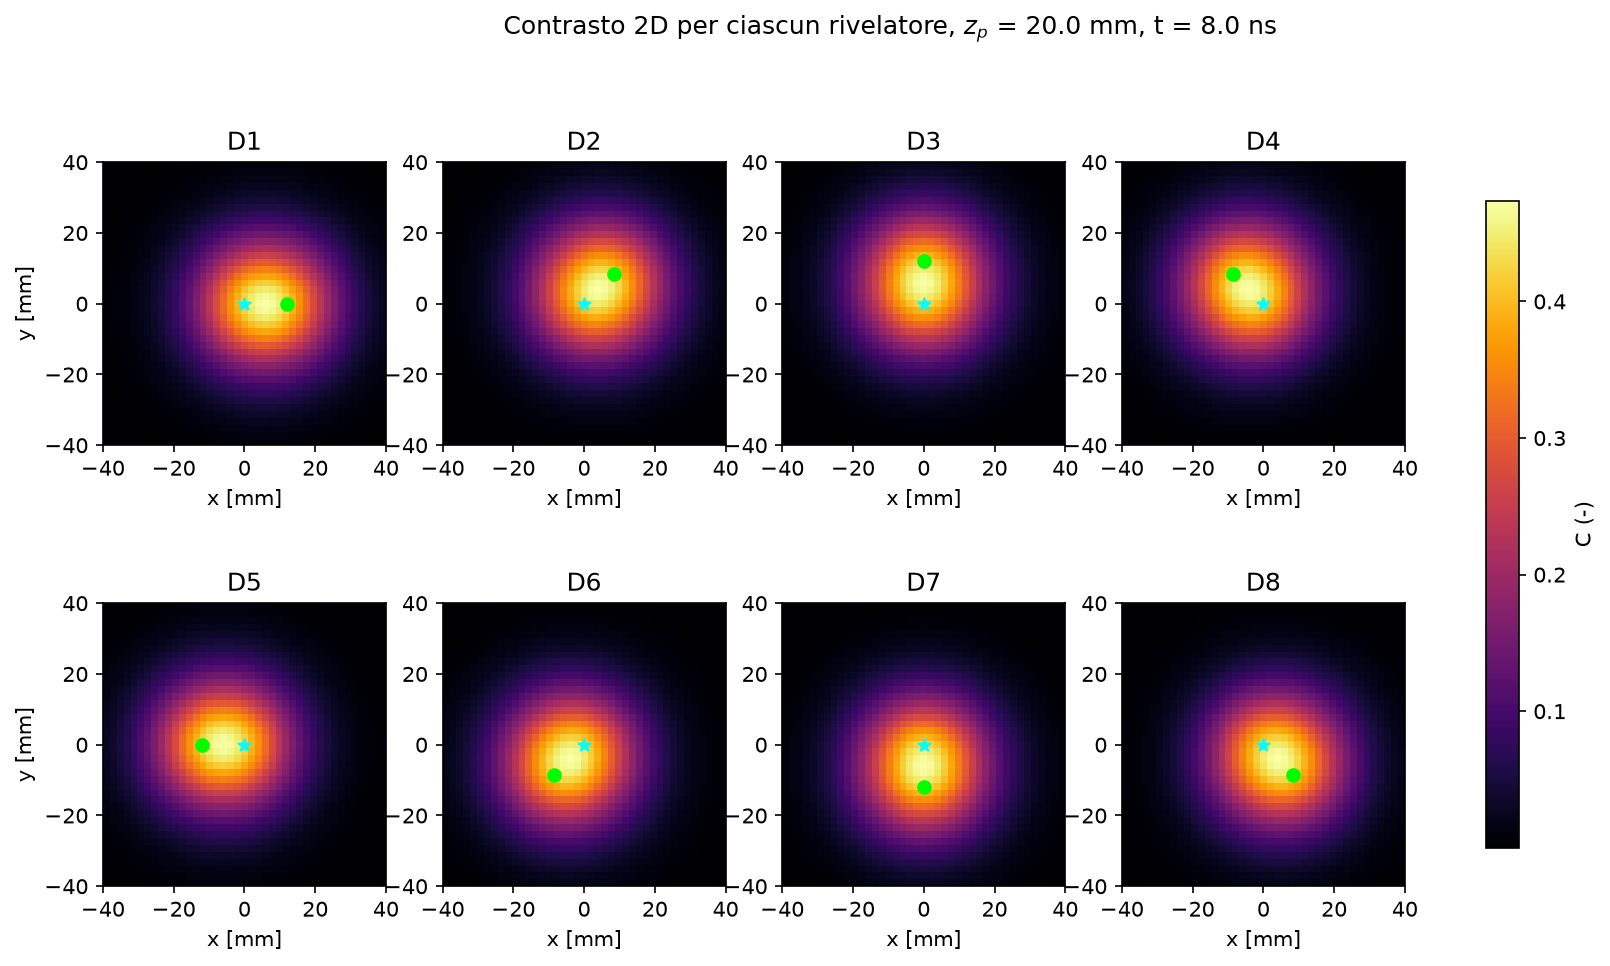

In [8]:
# --- Mappe 2D del contrasto (x,y), un pannello per rivelatore (zp, t fissati) ---
t_fix = 8.0
zp_fix = 20.0
xg = np.linspace(-40, 40, 41)
yg = np.linspace(-40, 40, 41)
Xg, Yg = np.meshgrid(xg, yg)

fig, axs = plt.subplots(2, 4, figsize=(14, 7))
axs = axs.flatten()
for d in range(N_det):
    C2d = np.zeros_like(Xg)
    for a in range(Xg.shape[0]):
        for b in range(Xg.shape[1]):
            rp = np.array([Xg[a, b], Yg[a, b], zp_fix])
            dphi = deltaphi_semiinf(mu_a0, mu_s0, n_idx, t_fix, dmu_a, V_incl,
                                     rp, r_s0, r_si, r_d0[d], r_di[d])
            phi0 = fluence_semiinf(mu_a0, mu_s0, n_idx, t_fix, r_d0[d], r_s0, r_si)
            C2d[a, b] = abs(dphi/phi0)
    im = axs[d].imshow(C2d, origin='lower', extent=(-40, 40, -40, 40), cmap='inferno')
    axs[d].scatter(0, 0, marker='*', c='cyan')
    axs[d].scatter(det_xy[d, 0], det_xy[d, 1], marker='o', c='lime')
    axs[d].set_title(f'D{d+1}')
    axs[d].set_xlabel('x [mm]')
axs[0].set_ylabel('y [mm]'); axs[4].set_ylabel('y [mm]')
fig.suptitle(f'Contrasto 2D per ciascun rivelatore, $z_p$ = {zp_fix} mm, t = {t_fix} ns')
fig.colorbar(im, ax=axs, shrink=0.8, label='C (-)')
plt.show()


**Teoria.** Estendendo il grafico precedente a un piano $(x_p,y_p)$
intero (a $z_p$ e $t$ fissati), si ottiene per ciascun rivelatore una vera
e propria **mappa di sensibilità**: il luogo dei punti dove un'inclusione
produrrebbe il massimo contrasto misurato da quel rivelatore. Questa è
concettualmente la base della tomografia: ogni coppia sorgente-rivelatore
campiona preferenzialmente una diversa regione del mezzo.

**Logica di programmazione.** `np.meshgrid` genera la griglia 2D
$(X_g,Y_g)$; per ogni rivelatore si itera con un doppio `for` su tutti i
punti della griglia (qui $41\times41=1681$ punti $\times$ 8 rivelatori):
ancora non vettorizzato, a differenza della costruzione della matrice $W$
in Parte 3, dove lo stesso calcolo verrà fatto per migliaia di voxel
sfruttando il broadcasting di NumPy. `axs.flatten()` permette di indicizzare
la griglia $2\times4$ di sottografici con un unico indice `d`; `imshow` con
`cmap='inferno'` visualizza l'intensità del contrasto, e i marker
ciano/verde riportano sorgente e rivelatore su ogni pannello per contesto
geometrico.

**Commento al grafico.** Il picco di contrasto in ciascun pannello si
sposta verso la posizione del rivelatore corrispondente (es. il pannello D3
mostra il picco spostato verso $+y$, dove si trova D3): conferma diretta
che ogni coppia sorgente-rivelatore campiona una diversa porzione del mezzo,
informazione che nell'originale (rivelatore unico coincidente con la
sorgente) non poteva nemmeno essere definita.


---
## Parte 2 — Griglia spazio-temporale
*(da `DOT_Part2_griglia_spaziotemporale.py`)*

Questo file introduce la discretizzazione richiesta per passare dal
problema continuo (Parte 1) al problema discreto (matrice di sensitività,
Parte 3): la griglia di **voxel** nello spazio e le **finestre temporali**
(time gates) nel tempo. Per rendere il file eseguibile in modo indipendente,
i parametri ottici e la geometria a 8 rivelatori vengono ridefiniti qui (li
abbiamo già commentati in Parte 1): il codice è identico, cambia solo lo
scopo — qui servono da base per costruire la griglia, non per calcolare
fluenza/contrasto punto per punto.


In [9]:
# STEP 1 - Richiamo dei parametri e geometria sorgente-rivelatori (identico a Parte 1)
mu_a0 = 0.01
mu_s0 = 1.00
n_idx = 1.4
D = 1/(3*mu_s0)
v = 3e2/n_idx

def A_coefficient(n):
    Reff = -1.4399/n**2 + 0.7099/n + 0.6681 + 0.0636*n
    return (1 + Reff)/(1 - Reff)

A_coeff = A_coefficient(n_idx)
z0 = 1/mu_s0
zb = 2*A_coeff*D

r_s0 = np.array([0.0, 0.0, z0])
r_si = np.array([0.0, 0.0, -z0 - 2*zb])

rho_sd = 12.0
angoli = np.arange(0, 360, 45)
det_xy = np.array([[rho_sd*np.cos(np.radians(a)),
                     rho_sd*np.sin(np.radians(a))] for a in angoli])
N_det = det_xy.shape[0]

r_d0 = np.column_stack((det_xy, np.full(N_det, z0)))
r_di = np.column_stack((det_xy, np.full(N_det, -z0 - 2*zb)))

print("Geometria richiamata:", N_det, "rivelatori, rho_sd =", rho_sd, "mm")


Geometria richiamata: 8 rivelatori, rho_sd = 12.0 mm


**Logica di programmazione.** Questo blocco **non introduce nuova
teoria** (è la stessa geometria della Parte 1, Step 2-3): la scelta di
progetto è che ciascuno dei tre file del repository sia **autosufficiente**
(eseguibile da solo, senza dover importare gli altri), a costo di duplicare
poche righe di inizializzazione. È una scelta didattica comune nei notebook
scientifici, dove ogni sezione deve poter essere rieseguita/ispezionata
indipendentemente dalle altre.


Numero totale di voxel N_vox = 2048, volume voxel = 64.0 mm^3


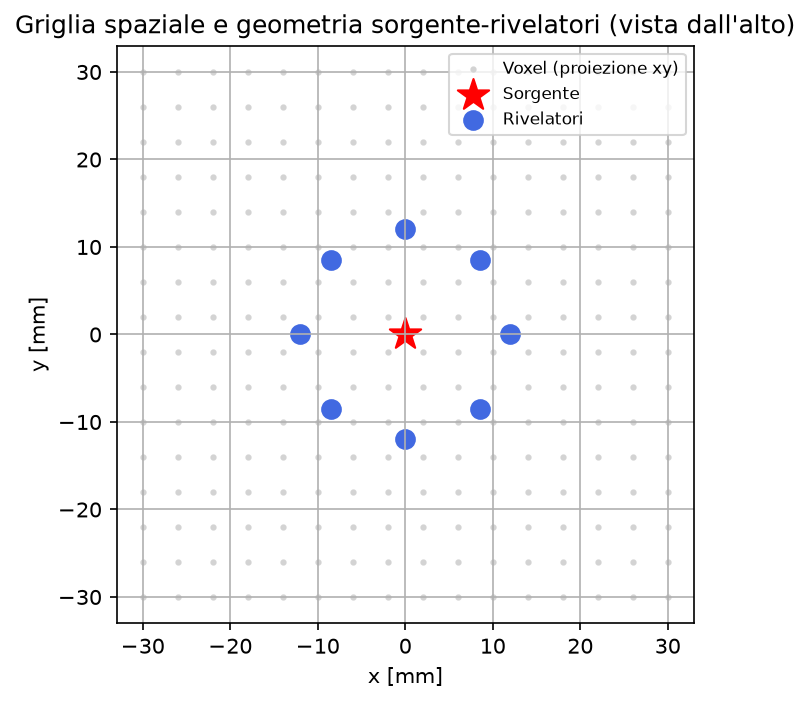

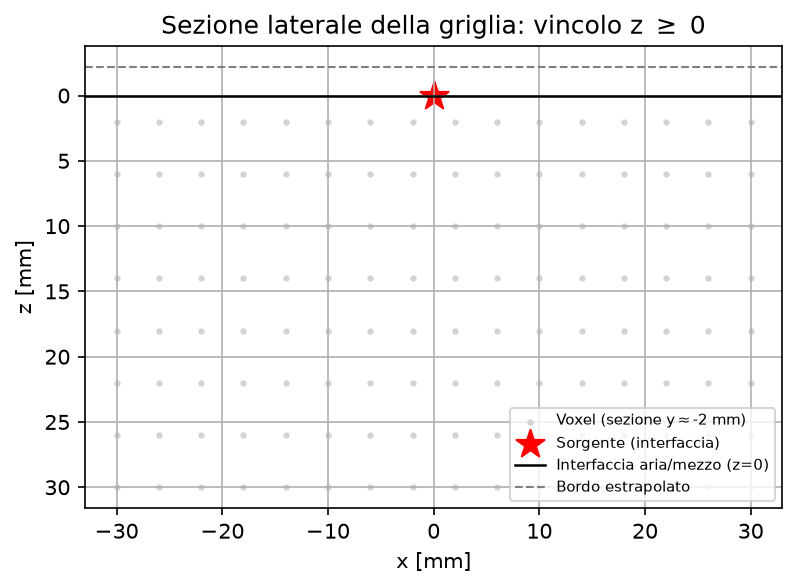

In [10]:
# STEP 2 - Griglia spaziale (discretizzazione in voxel)
step = 4.0                        # lato del voxel [mm]
x_ext = 64.0                      # estensione totale del dominio in x,y [mm]
z_ext = 32.0                      # estensione massima in profondita' [mm]
                                   # (dimezzata rispetto alla versione originale: 64 -> 32 mm)

x_coords = np.arange(-x_ext/2 + step/2, x_ext/2, step)
y_coords = np.arange(-x_ext/2 + step/2, x_ext/2, step)
z_coords = np.arange(0 + step/2, z_ext, step)     # SOLO z >= 0 (ipotesi 3)

X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing='ij')
r_V = np.column_stack((X.flatten(), Y.flatten(), Z.flatten()))
N_vox = r_V.shape[0]
V_vox = step**3

print(f"Numero totale di voxel N_vox = {N_vox}, volume voxel = {V_vox} mm^3")

# --- vista dall'alto: griglia + geometria sorgente-rivelatori ---
plt.figure(figsize=(5, 5))
plt.scatter(X[:, :, 0].flatten(), Y[:, :, 0].flatten(), s=4, c='lightgray',
            label='Voxel (proiezione xy)')
plt.scatter(0, 0, marker='*', s=250, c='red', label='Sorgente')
plt.scatter(det_xy[:, 0], det_xy[:, 1], marker='o', s=80, c='royalblue',
            label='Rivelatori')
plt.gca().set_aspect('equal')
plt.xlabel('x [mm]'); plt.ylabel('y [mm]')
plt.title('Griglia spaziale e geometria sorgente-rivelatori (vista dall\'alto)')
plt.grid(); plt.legend(loc='upper right', fontsize=8)
plt.show()

# --- vista laterale (piano xz, sezione a y piu' vicino a 0) ---
iy0 = np.argmin(np.abs(y_coords))
plt.figure(figsize=(6, 4))
plt.scatter(X[:, iy0, :].flatten(), Z[:, iy0, :].flatten(), s=4, c='lightgray',
            label='Voxel (sezione y$\\approx$%.0f mm)' % y_coords[iy0])
plt.scatter(0, 0, marker='*', s=200, c='red', label='Sorgente (interfaccia)')
plt.axhline(0, color='k', linewidth=1.2, label='Interfaccia aria/mezzo (z=0)')
plt.axhline(-zb, color='gray', linestyle='--', linewidth=1, label='Bordo estrapolato')
plt.gca().invert_yaxis()
plt.xlabel('x [mm]'); plt.ylabel('z [mm]')
plt.title('Sezione laterale della griglia: vincolo z $\\geq$ 0')
plt.grid(); plt.legend(loc='lower right', fontsize=7)
plt.show()


**Teoria.** Per costruire numericamente la matrice di sensitività
occorre discretizzare lo spazio in **voxel** cubici di lato `step`. A
differenza di un mezzo infinito (dove il dominio da discretizzare sarebbe
simmetrico anche in $z$), qui il piano $z=0$ è l'interfaccia fisica
aria/mezzo (ipotesi 3): la griglia si estende **solo per $z\ge 0$**. In $x$
e $y$, essendo la sorgente nell'origine e i rivelatori disposti
simmetricamente attorno ad essa, il dominio resta simmetrico e comprende
coordinate negative, con la stessa estensione lungo entrambi gli assi.

**Logica di programmazione.** `np.arange(step/2, x_ext-step/2+..., step)`
genera le coordinate dei **centri** dei voxel (non i loro spigoli): partendo
da mezzo passo dal bordo del dominio, ogni valore rappresenta il centro
della cella, comodo per valutare formule analitiche puntiformi al centro di
ciascun volumetto. `np.meshgrid(..., indexing='ij')` produce tre array 3D
$(X,Y,Z)$ della stessa forma; `column_stack` + `flatten()` li trasforma
nella lista $(N_{\rm vox}\times3)$ `r_V`, dove `r_V[m]` è la posizione del
voxel $m$-esimo secondo un **indice lineare** che verrà riusato, in Parte 3,
per costruire per colonne la matrice $W$ e il vettore $A$ — è fondamentale
che questa corrispondenza indice$\leftrightarrow$voxel resti coerente in
tutto il progetto.

**Commento ai grafici.** La vista dall'alto mostra come il dominio dei
voxel copra ampiamente la zona degli 8 rivelatori ($\rho_{sd}=12$ mm),
lasciando margine per inclusioni anche fuori dal cerchio sorgente-
rivelatori. La sezione laterale rende esplicito il vincolo $z\ge0$: i voxel
esistono solo sotto l'interfaccia, mentre il bordo estrapolato (tratteggiato,
a $z=-z_b$) cade **fuori** dal dominio fisico — è un artificio matematico
del metodo delle immagini (Parte 1), non una regione dello spazio reale.


Numero di finestre temporali (time gates): 8
  Gate 0: 1.0 - 2.0 ns
  Gate 1: 2.0 - 3.0 ns
  Gate 2: 3.0 - 4.0 ns
  Gate 3: 4.0 - 5.0 ns
  Gate 4: 5.0 - 6.0 ns
  Gate 5: 6.0 - 7.0 ns
  Gate 6: 7.0 - 8.0 ns
  Gate 7: 8.0 - 9.0 ns


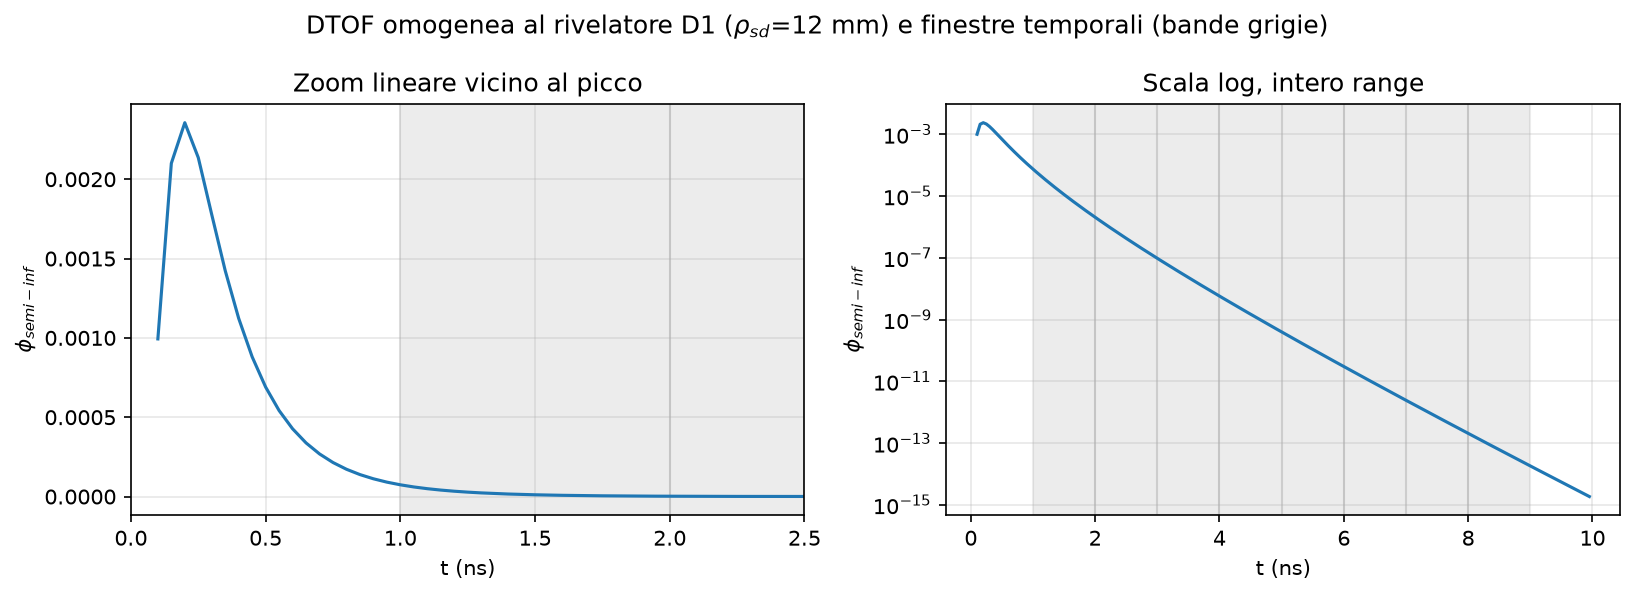

In [11]:
# STEP 3 - Discretizzazione temporale (finestre / time gates)
dt = 0.05                          # passo di campionamento [ns]
t = np.arange(0.1, 10.0, dt)       # asse dei tempi [ns]
N_gates = 8
gates = [(1.0 + i, 2.0 + i) for i in range(N_gates)]     # bordi delle finestre [ns]
gate_indices = [(np.searchsorted(t, g[0]), np.searchsorted(t, g[1])) for g in gates]

print(f"Numero di finestre temporali (time gates): {N_gates}")
for k, (g0, g1) in enumerate(gates):
    print(f"  Gate {k}: {g0:.1f} - {g1:.1f} ns")

# --- fluenza omogenea semi-infinita al rivelatore D1, con i gate sovrapposti ---
def fluence_inf(mu_a0, mu_s0, n, t, r):
    D = 1/(3*mu_s0); v = 3e2/n
    return (v/(4*pi*D*v*t)**(3/2))*exp(-(r**2/(4*D*v*t))-mu_a0*v*t)

d_show = 0
r_d_s  = np.linalg.norm(r_d0[d_show] - r_s0)
r_d_si = np.linalg.norm(r_d0[d_show] - r_si)
phi0_demo = fluence_inf(mu_a0, mu_s0, n_idx, t, r_d_s) - fluence_inf(mu_a0, mu_s0, n_idx, t, r_d_si)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(t, phi0_demo)
axs[0].set_xlim(0, 2.5)
axs[0].set_xlabel('t (ns)'); axs[0].set_ylabel(r'$\phi_{semi-inf}$')
axs[0].set_title('Zoom lineare vicino al picco'); axs[0].grid(alpha=0.3)
axs[1].semilogy(t, phi0_demo)
axs[1].set_xlabel('t (ns)'); axs[1].set_ylabel(r'$\phi_{semi-inf}$')
axs[1].set_title('Scala log, intero range'); axs[1].grid(alpha=0.3)
for (g0, g1) in gates:
    axs[0].axvspan(g0, g1, color='gray', alpha=0.15)
    axs[1].axvspan(g0, g1, color='gray', alpha=0.15)
fig.suptitle(f'DTOF omogenea al rivelatore D1 ($\\rho_{{sd}}$={rho_sd:.0f} mm) '
             'e finestre temporali (bande grigie)')
plt.tight_layout()
plt.show()


**Teoria.** Una misura reale time-resolved non campiona la DTOF
(*distribution of times of flight*) a tempo continuo, ma la integra su un
numero finito di **finestre temporali** (time gates):

$$
M_{\rm gate} = \int_{t_{g0}}^{t_{g1}} \phi(t)\,dt .
$$

Qui si definiscono 8 gate contigui di ampiezza 1 ns (da 1-2 ns a 8-9 ns).

**Logica di programmazione.** `gates` è una lista di tuple $(t_{g0},t_{g1})$
costruita per comprensione; `gate_indices` converte i confini "fisici" (in
ns) negli **indici interi** dell'array `t` corrispondenti, tramite
`np.searchsorted`: così l'integrazione (fatta con la regola dei trapezi in
Parte 3) potrà operare per semplice *slicing* `t[i0:i1]`, senza dover
ricalcolare il confine ogni volta che serve. Il grafico usa
`plt.axvspan` per sovrapporre le bande grigie dei gate sulla DTOF, in scala
sia lineare (per vedere il picco) sia logaritmica (per vedere l'intera coda).

**Commento al grafico.** Il pannello lineare mostra il picco della DTOF,
raggiunto entro il primo nanosecondo; il pannello log mostra la coda a
decadimento esponenziale. I gate scelti (1-9 ns) cadono interamente nella
coda, ben oltre il picco: è lì che la forma della curva è dominata
dall'assorbimento ($\mu_a$), rendendo i gate tardivi più sensibili a
piccole variazioni di $\mu_a$ (il segnale utile per la ricostruzione)
rispetto ai gate precoci, più sensibili a $\mu_s'$ e alla geometria vicino
alla sorgente.


---
## Parte 3 — Matrice di sensitività $W$, vettore voxel $A$, misure $M$
*(da `DOT_Part2_W_A_M_senza_rumore.py`)*

Obiettivo: costruire la matrice di sensitività (Jacobiano) $W$ tale che, per
qualunque distribuzione di perturbazioni di assorbimento nello spazio dei
voxel rappresentata dal vettore $A$, il vettore delle misure (contrasto, per
rivelatore e per time-gate) sia

$$M = W\cdot A,$$

esatto nel limite dell'approssimazione di Born al prim'ordine, senza rumore
né altre approssimazioni aggiuntive (che potranno essere introdotte in un
secondo momento sopra questa stessa struttura, in fase di ricostruzione).


In [12]:
# STEP 1 - Richiamo delle grandezze di Parte 1 e della griglia (per rendere
#          il file autosufficiente)
# --- proprieta' ottiche di base e bordo estrapolato ---
mu_a0 = 0.01
mu_s0 = 1.00
n_idx = 1.4
D = 1/(3*mu_s0)
v = 3e2/n_idx

def A_coefficient(n):
    Reff = -1.4399/n**2 + 0.7099/n + 0.6681 + 0.0636*n
    return (1 + Reff)/(1 - Reff)

A_coeff = A_coefficient(n_idx)
z0 = 1/mu_s0
zb = 2*A_coeff*D

r_s0 = np.array([0.0, 0.0, z0])
r_si = np.array([0.0, 0.0, -z0 - 2*zb])

# --- geometria a 8 rivelatori a raggiera ---
rho_sd = 12.0
angoli = np.arange(0, 360, 45)
det_xy = np.array([[rho_sd*np.cos(np.radians(a)),
                     rho_sd*np.sin(np.radians(a))] for a in angoli])
N_det = det_xy.shape[0]
r_d0 = np.column_stack((det_xy, np.full(N_det, z0)))
r_di = np.column_stack((det_xy, np.full(N_det, -z0 - 2*zb)))

# --- griglia spaziale, z>=0 ---
step = 4.0
x_ext = 64.0
z_ext = 32.0     # dimezzata rispetto alla versione originale (64 -> 32 mm)
x_coords = np.arange(-x_ext/2 + step/2, x_ext/2, step)
y_coords = np.arange(-x_ext/2 + step/2, x_ext/2, step)
z_coords = np.arange(0 + step/2, z_ext, step)
X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing='ij')
r_V = np.column_stack((X.flatten(), Y.flatten(), Z.flatten()))
N_vox = r_V.shape[0]
V_vox = step**3

# --- discretizzazione temporale, time gates ---
dt = 0.05
t = np.arange(0.1, 10.0, dt)
N_gates = 8
gates = [(1.0 + i, 2.0 + i) for i in range(N_gates)]
gate_indices = [(np.searchsorted(t, g[0]), np.searchsorted(t, g[1])) for g in gates]

print("="*55)
print("RICHIAMO: N_det =", N_det, "| N_vox =", N_vox, "| N_gates =", N_gates)
print(f"Misurazioni indipendenti: {N_det*N_gates}  |  Incognite (voxel): {N_vox}")
print("="*55 + "\n")


RICHIAMO: N_det = 8 | N_vox = 2048 | N_gates = 8
Misurazioni indipendenti: 64  |  Incognite (voxel): 2048



**Logica di programmazione.** Ancora una volta il file si presenta
autosufficiente, ridefinendo tutte le grandezze di Parte 1 e Parte 2. Il
`print` finale anticipa la struttura del **problema inverso** che verrà
affrontato più avanti: con $N_{\rm det}=8$ rivelatori e $N_{\rm gates}=8$
finestre temporali si hanno $8\times8=64$ misurazioni indipendenti, a
fronte di $N_{\rm vox}$ incognite (una per voxel).

**Nota su questa revisione: $z_{\rm ext}$ dimezzato (64 → 32 mm).** Rispetto alla
versione precedente di questo notebook, qui il dominio in profondità è stato
ridotto a 32 mm (era 64 mm), lasciando invariati `step` (4 mm) ed $x_{\rm
ext}=y_{\rm ext}=64$ mm. Poiché il numero di voxel lungo $z$ è
$\lfloor z_{\rm ext}/{\rm step}\rfloor$, dimezzare $z_{\rm ext}$ dimezza
(circa) anche $N_{\rm vox}$ totale, mentre $N_{\rm det}\cdot N_{\rm gates}=64$
resta fisso: il **rapporto misure/incognite raddoppia**. Il problema resta
ampiamente **sotto-determinato** ($N_{\rm vox}$ è ancora dell'ordine delle
migliaia), ma **meno** di prima — è esattamente l'effetto che ci si aspetta
restringendo il volume da ricostruire, e lo si vedrà nei numeri stampati
sopra confrontati con la versione a piena profondità. Resta comunque
giustificato, nella fase di ricostruzione, il ricorso a tecniche di
regolarizzazione/decomposizione ai valori singolari (SVD), come nel progetto
originale di riferimento.


Voxel selezionati: 16 | Volume effettivo: 1024.0 mm^3


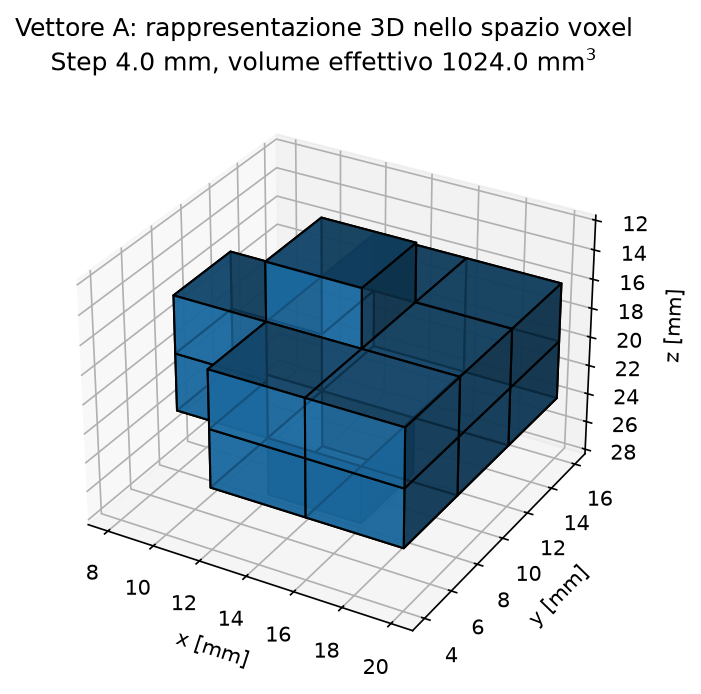

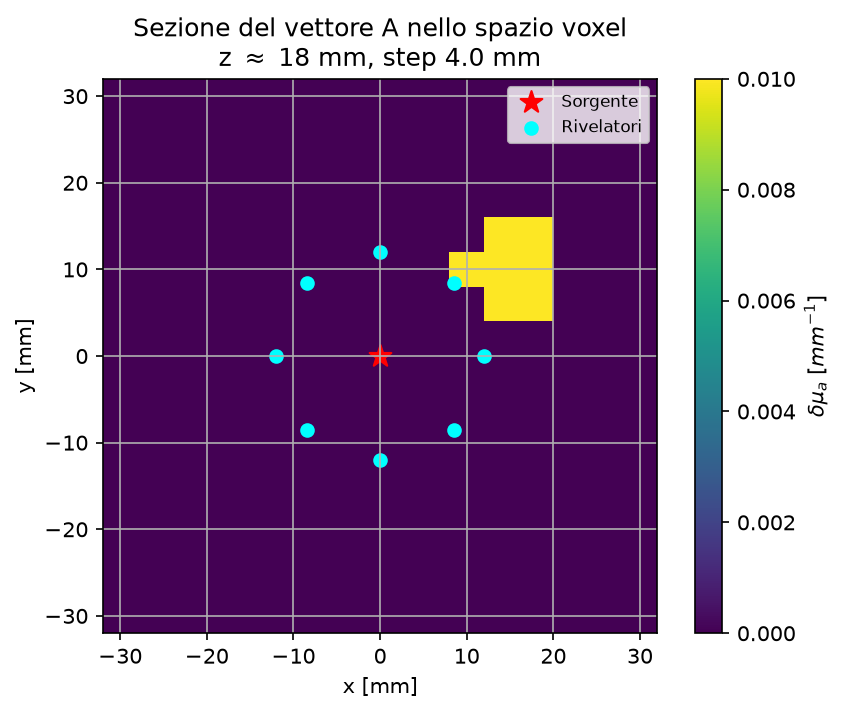

In [13]:
# STEP 2 - Vettore dei voxel A: mappatura di un'inclusione nello
#          spazio discretizzato
dmu_a = 0.01           # variazione di assorbimento dell'inclusione [mm^-1]
V_incl = 1000.0        # volume dell'inclusione [mm^3]
r_eq = (V_incl*3/(4*pi))**(1/3)

xp, yp, zp = 15.0, 10.0, 20.0     # posizione dell'inclusione [mm]

mask = (X - xp)**2 + (Y - yp)**2 + (Z - zp)**2 < r_eq**2
A_rep = mask*dmu_a                # rappresentazione 3D di A (per i grafici)
A = A_rep.flatten()               # vettore voxel 1D (stesso ordine di r_V)
V_eff = V_vox*int(np.sum(mask))

print(f"Voxel selezionati: {int(np.sum(mask))} | Volume effettivo: {V_eff} mm^3")

# --- rappresentazione 3D del vettore A nello spazio dei voxel ---
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection='3d')
x_edges = np.linspace(x_coords[0]-step/2, x_coords[-1]+step/2, x_coords.size+1)
y_edges = np.linspace(y_coords[0]-step/2, y_coords[-1]+step/2, y_coords.size+1)
z_edges = np.linspace(0, z_coords[-1]+step/2, z_coords.size+1)
Xe, Ye, Ze = np.meshgrid(x_edges, y_edges, z_edges, indexing='ij')
ax.voxels(Xe, Ye, Ze, A_rep, edgecolor='k', alpha=0.8)
ax.set(xlabel='x [mm]', ylabel='y [mm]', zlabel='z [mm]')
ax.invert_zaxis()
fig.suptitle(f"Vettore A: rappresentazione 3D nello spazio voxel\n"
             f"Step {step} mm, volume effettivo {V_eff} mm$^3$")
plt.show()

# --- sezione 2D nel piano z piu' vicino a zp, con sorgente e rivelatori ---
iz = np.argmin(np.abs(z_coords - zp))
plt.figure()
im = plt.imshow(A_rep[:, :, iz].T, origin='lower',
                 extent=(x_coords[0]-step/2, x_coords[-1]+step/2,
                         y_coords[0]-step/2, y_coords[-1]+step/2),
                 vmin=0, vmax=dmu_a)
plt.scatter(0, 0, marker='*', c='red', s=120, label='Sorgente')
plt.scatter(det_xy[:, 0], det_xy[:, 1], marker='o', c='cyan', label='Rivelatori')
plt.xlabel('x [mm]'); plt.ylabel('y [mm]')
plt.title(f"Sezione del vettore A nello spazio voxel\n"
          f"z $\\approx$ {z_coords[iz]:.0f} mm, step {step} mm")
plt.legend(fontsize=8)
plt.colorbar(im, label=r'$\delta\mu_a$ [$mm^{-1}$]')
plt.grid(); plt.show()


**Teoria.** Il vettore $A$ è la rappresentazione discreta della
perturbazione fisica: $A[m]=\delta\mu_a$ nel voxel $m$-esimo (zero dove il
mezzo è omogeneo). Per un'inclusione sferica di volume assegnato
$V_{\rm incl}$ centrata in $(x_p,y_p,z_p)$, il raggio equivalente è

$$
r_{\rm eq} = \Big(\frac{3\,V_{\rm incl}}{4\pi}\Big)^{1/3}.
$$

Un voxel appartiene all'inclusione se il suo **centro** ricade dentro la
sfera, $|\vec r_{\rm voxel}-\vec r_p| < r_{\rm eq}$. Il volume della sfera
non è in generale un multiplo esatto del volume del voxel, quindi il
"volume effettivo" discretizzato $V_{\rm eff}=V_{\rm vox}\times(\text{voxel
selezionati})$ approssima $V_{\rm incl}$ con un errore dell'ordine di un
voxel di superficie della sfera — inevitabile passando da una geometria
continua a una griglia discreta, tanto più piccolo quanto più fine è `step`.

**Logica di programmazione.** `mask` è un array booleano 3D (stessa forma
di $X,Y,Z$), `True` nei voxel dentro la sfera; moltiplicato per `dmu_a` dà
la rappresentazione 3D `A_rep` (per i grafici), mentre `A_rep.flatten()` dà
il vettore 1D `A` **nello stesso ordine lineare di `r_V`**: è un punto
critico, perché `A[m]` deve riferirsi allo stesso voxel di `r_V[m]`,
altrimenti il prodotto `M = W @ A` (Step 4) mescolerebbe l'informazione fra
voxel diversi. Il grafico 3D usa `ax.voxels` con array di *edges* (spigoli,
non centri) delle celle, costruiti con `np.linspace`; `ax.invert_zaxis()`
fa apparire $z$ crescente verso il basso, coerente con la profondità fisica.

**Nota (bug corretto).** Nella sezione 2D, `plt.imshow(...)` va assegnato a
una variabile (`im = plt.imshow(...)`) e passato esplicitamente a
`plt.colorbar(im, ...)`. Il motivo non è stilistico: in Matplotlib,
`plt.scatter(...)` — anche con un colore fisso come `c='cyan'` — registra
comunque la propria collezione di punti come "immagine corrente" per
`pyplot`. Chiamando `plt.colorbar(...)` **senza** argomento esplicito
*dopo* i due `plt.scatter(...)` di sorgente/rivelatori, la colorbar viene
agganciata silenziosamente allo scatter (che non ha un intervallo di colori
proprio, e di default assume $[0,1]$) invece che all'immagine: il risultato
è una colorbar che mostra $0$–$1$ anziché $0$–$\delta\mu_a$, pur essendo i
dati e l'immagine sullo schermo corretti. È un errore silenzioso — nessuna
eccezione, nessun warning — individuato eseguendo effettivamente questo
grafico per la presente relazione, e ora corretto nel file sorgente.

**Commento ai grafici.** La vista 3D mostra il "grumo" di voxel attivati
dall'inclusione. La sezione 2D, presa al piano $z$ più vicino a $z_p=20$
mm, mostra l'inclusione ($x_p=15$, $y_p=10$) in posizione **asimmetrica**
rispetto alla sorgente (stella, nell'origine) e ai rivelatori (cerchi, sul
cerchio di raggio 12 mm): a differenza del progetto originale (dove
l'inclusione era spesso posta sull'asse sorgente-rivelatore per simmetria),
qui la geometria a 8 rivelatori rende ogni posizione "vista" in modo diverso
da ciascun rivelatore — l'informazione che permetterà, in fase di
ricostruzione, di localizzarla per triangolazione.


Matrice W costruita: shape = (64, 2048)


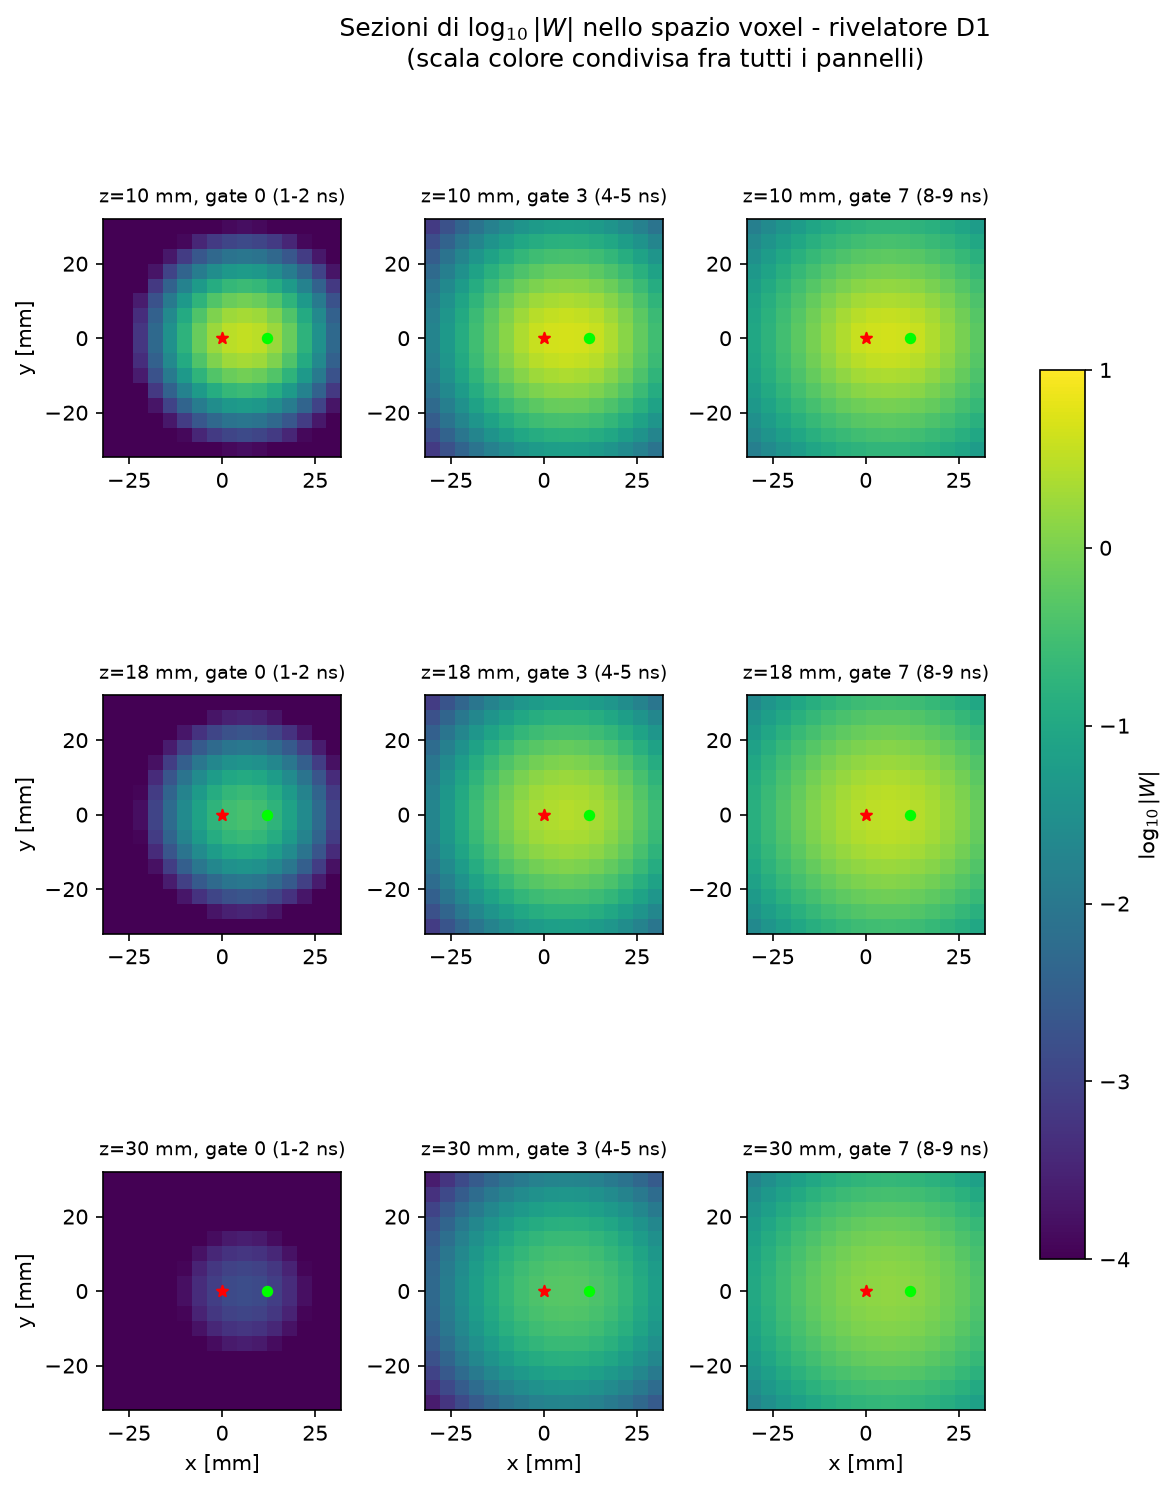

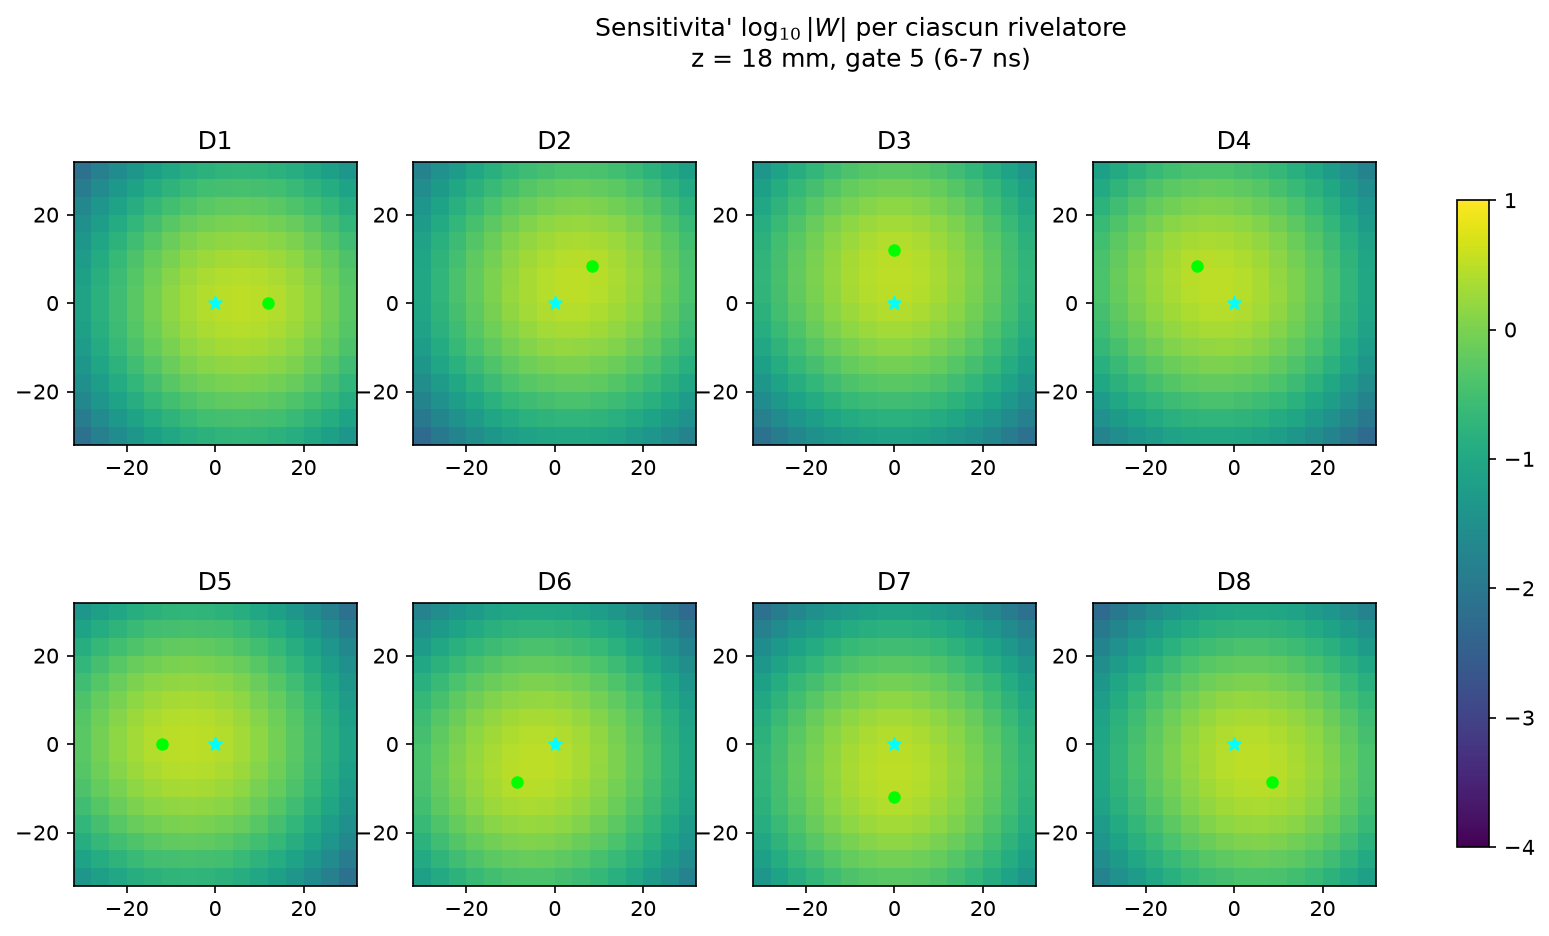

In [14]:
# STEP 3 - Costruzione della matrice di sensitivita' (Jacobiano) W
def deltafluence_inf(mu_a0, mu_s0, t, dmu_a, V, r, r1, n=n_idx):
    '''Perturbazione di fluenza (Born, I ordine) in mezzo infinito, fra
    un punto sorgente(-immagine) a distanza r dal voxel e un punto
    rivelatore(-immagine) a distanza r1 dal voxel. Supporta il
    broadcasting di numpy: r, r1, t possono essere scalari o array de
    forme compatibili (qui: r,r1 colonna (N_vox,1), t riga (1,N_t)).'''
    D = 1/(3*mu_s0)
    v = 3e2/n
    return (-(v**2)/((4*pi*D*v)**(5/2)*t**(3/2))*exp(-mu_a0*v*t)
            * dmu_a*V*(1/r + 1/r1)*exp(-(r+r1)**2/(4*D*v*t)))

def fluence_inf(mu_a0, mu_s0, n, t, r):
    D = 1/(3*mu_s0); v = 3e2/n
    return (v/(4*pi*D*v*t)**(3/2))*exp(-(r**2/(4*D*v*t)) - mu_a0*v*t)

_trapz = getattr(np, "trapezoid", None) or np.trapz

r_sv  = np.linalg.norm(r_V - r_s0, axis=1)     # sorgente reale -> ogni voxel
r_siv = np.linalg.norm(r_V - r_si, axis=1)     # sorgente immagine -> ogni voxel

W = np.zeros((N_det*N_gates, N_vox))
tt = t[None, :]                                # riga (1, N_t), per il broadcasting

for d in range(N_det):
    r_vd  = np.linalg.norm(r_V - r_d0[d], axis=1)   # voxel -> rivelatore reale
    r_vdi = np.linalg.norm(r_V - r_di[d], axis=1)   # voxel -> rivelatore immagine

    dphi_vt = (deltafluence_inf(mu_a0, mu_s0, tt, 1.0, V_vox, r_sv[:, None],  r_vd[:, None])
             - deltafluence_inf(mu_a0, mu_s0, tt, 1.0, V_vox, r_sv[:, None],  r_vdi[:, None])
             - deltafluence_inf(mu_a0, mu_s0, tt, 1.0, V_vox, r_siv[:, None], r_vd[:, None])
             + deltafluence_inf(mu_a0, mu_s0, tt, 1.0, V_vox, r_siv[:, None], r_vdi[:, None]))

    r_d_s  = np.linalg.norm(r_d0[d] - r_s0)
    r_d_si = np.linalg.norm(r_d0[d] - r_si)
    phi0_t = fluence_inf(mu_a0, mu_s0, n_idx, t, r_d_s) - fluence_inf(mu_a0, mu_s0, n_idx, t, r_d_si)

    for g, (i0, i1) in enumerate(gate_indices):
        int_dphi = _trapz(dphi_vt[:, i0:i1], dx=dt, axis=1)   # (N_vox,)
        int_phi0 = _trapz(phi0_t[i0:i1], dx=dt)                # scalare
        W[d*N_gates + g, :] = int_dphi / int_phi0

print(f"Matrice W costruita: shape = {W.shape}")

# --- sezioni 2D di W per il rivelatore D1, a diverse profondita' e gate ---
W_3d = W.reshape(N_det, N_gates, x_coords.size, y_coords.size, z_coords.size)
d_show = 0
z_show = [10.0, 20.0, 30.0]
g_show = [0, 3, 7]
Wlog_vmin, Wlog_vmax = -4, 1
fig, axs = plt.subplots(3, 3, figsize=(10, 11))
for r_i, zval in enumerate(z_show):
    iz = np.argmin(np.abs(z_coords - zval))
    for c_i, g in enumerate(g_show):
        Wsec = np.log10(np.clip(np.abs(W_3d[d_show, g, :, :, iz]), 1e-8, None)).T
        im = axs[r_i, c_i].imshow(Wsec, origin='lower', vmin=Wlog_vmin, vmax=Wlog_vmax,
                extent=(x_coords[0]-step/2, x_coords[-1]+step/2,
                        y_coords[0]-step/2, y_coords[-1]+step/2))
        axs[r_i, c_i].scatter(0, 0, marker='*', c='red', s=30)
        axs[r_i, c_i].scatter(det_xy[d_show, 0], det_xy[d_show, 1], marker='o', c='lime', s=20)
        axs[r_i, c_i].set_title(f"z={z_coords[iz]:.0f} mm, gate {g} "
                                 f"({gates[g][0]:.0f}-{gates[g][1]:.0f} ns)", fontsize=9, pad=8)
        if c_i == 0: axs[r_i, c_i].set_ylabel('y [mm]')
        if r_i == 2: axs[r_i, c_i].set_xlabel('x [mm]')
fig.subplots_adjust(hspace=0.5, wspace=0.35, top=0.88, right=0.86)
fig.suptitle(r'Sezioni di $\log_{10}|W|$ nello spazio voxel - rivelatore D1'
             '\n(scala colore condivisa fra tutti i pannelli)')
fig.colorbar(im, ax=axs, shrink=0.7, label=r'$\log_{10}|W|$')
plt.show()

# --- confronto fra tutti gli 8 rivelatori, a profondita' e gate fissati ---
z_fix = 20.0
g_fix = 5
iz = np.argmin(np.abs(z_coords - z_fix))
fig, axs = plt.subplots(2, 4, figsize=(14, 7))
axs = axs.flatten()
for d in range(N_det):
    Wsec = np.log10(np.clip(np.abs(W_3d[d, g_fix, :, :, iz]), 1e-8, None)).T
    im = axs[d].imshow(Wsec, origin='lower', vmin=Wlog_vmin, vmax=Wlog_vmax,
                extent=(x_coords[0]-step/2, x_coords[-1]+step/2,
                        y_coords[0]-step/2, y_coords[-1]+step/2))
    axs[d].scatter(0, 0, marker='*', c='cyan', s=40)
    axs[d].scatter(det_xy[d, 0], det_xy[d, 1], marker='o', c='lime', s=25)
    axs[d].set_title(f'D{d+1}')
fig.suptitle(f"Sensitivita' " r"$\log_{10}|W|$" f" per ciascun rivelatore\n"
             f"z = {z_coords[iz]:.0f} mm, gate {g_fix} "
             f"({gates[g_fix][0]:.0f}-{gates[g_fix][1]:.0f} ns)")
fig.colorbar(im, ax=axs, shrink=0.8)
plt.show()


**Teoria.** Generalizzando la formula del contrasto (Parte 1, Step 5)
a un generico voxel $m$ e rivelatore $d$, la sensitività della misura al
time-gate $g$ è

$$
W[d,g,m] = \frac{\displaystyle\int_{\rm gate\ g} \delta\phi_{\rm semiinf}(m,d,t)\,dt}
{\displaystyle\int_{\rm gate\ g} \phi_{\rm semiinf}(d,t)\,dt},
$$

dove $\delta\phi_{\rm semiinf}$ è la somma a 4 immagini già derivata in
Parte 1 (Step 5), qui valutata con volume di riferimento $V_{\rm vox}$ e
$\delta\mu_a$ **unitario** ($=1$). Poiché $\delta\phi_{\rm semiinf}$ è
lineare in $\delta\mu_a$ (Born al prim'ordine), $W$ **non dipende dal
valore di $A$**: è una proprietà del solo sistema (geometria + ottica),
esattamente come uno Jacobiano. È questo che rende vera, per costruzione,
la relazione $M=W\cdot A$ per **qualunque** distribuzione $A$ (somma di più
inclusioni, forme arbitrarie), non solo per la singola inclusione sferica
dello Step 2: la linearità del prim'ordine di Born si eredita direttamente
nella struttura matrice$\times$vettore.

**Logica di programmazione (vettorizzazione).** Per ogni rivelatore `d`, le
4 distanze voxel-sorgente(i)/voxel-rivelatore(i) sono calcolate come array
di lunghezza $N_{\rm vox}$ in un colpo solo (`np.linalg.norm(..., axis=1)`).
`deltafluence_inf` viene poi valutata per **tutti i voxel e tutti i tempi
contemporaneamente**: passando le distanze come colonna `(N_vox,1)` e i
tempi come riga `(1,N_t)`, il broadcasting di NumPy produce direttamente una
matrice `(N_vox,N_t)` in un'unica chiamata, al posto di un ciclo Python per
ogni voxel — con $N_{\rm vox}$ dell'ordine delle migliaia, questo evita un
rallentamento di ordini di grandezza. L'integrazione nei gate resta un
semplice `np.trapz`/`np.trapezoid` per *slicing* sull'asse dei tempi (il
fallback `_trapz` gestisce la rinomina della funzione fra versioni diverse
di NumPy). Nei grafici, l'uso di un `vmin`/`vmax` **condiviso** fra tutti i
pannelli (anziché lasciare che ciascun `imshow` si auto-scali) è
intenzionale: altrimenti il crollo di sensitività con la profondità —
l'informazione fisica più importante di questi grafici — resterebbe
nascosto dietro una normalizzazione locale.

**Commento ai grafici.** Nella prima figura (rivelatore D1), la regione di
alta sensitività è una "banana" stretta fra sorgente e rivelatore al gate
precoce (colonna sinistra), tanto più confinata in superficie quanto minore
è la profondità $z$ (il pannello $z=30$ mm/gate 0 è quasi ovunque scuro: a
profondità elevate pochissimi fotoni sono già arrivati al rivelatore in una
finestra così precoce). Ai gate tardivi (colonna destra) la sensitività si
espande fino a occupare gran parte del dominio, significativa anche in
profondità — coerente con l'allargamento del "cono" di diffusione nel tempo
già osservato per la DTOF omogenea (Parte 2, Step 3): è il motivo per cui,
in DOT time-resolved, i gate tardivi sono i più informativi per rivelare
inclusioni profonde. La seconda figura mostra che tutti gli 8 rivelatori,
ruotati di $45^\circ$ l'uno rispetto all'altro, hanno la stessa forma di
sensitività orientata secondo la propria direzione azimutale: conseguenza
diretta della simmetria di rotazione della geometria a raggiera.


VETTORE DELLE MISURE M = W . A (ideale, senza rumore)
  D1: -0.0067 -0.0503 -0.1115 -0.1660 -0.2083 -0.2396 -0.2626 -0.2793
  D2: -0.0101 -0.0650 -0.1356 -0.1957 -0.2410 -0.2739 -0.2976 -0.3146
  D3: -0.0037 -0.0331 -0.0806 -0.1264 -0.1639 -0.1928 -0.2146 -0.2309
  D4: -0.0008 -0.0123 -0.0381 -0.0684 -0.0966 -0.1203 -0.1396 -0.1550
  D5: -0.0003 -0.0058 -0.0219 -0.0439 -0.0663 -0.0866 -0.1040 -0.1184
  D6: -0.0002 -0.0049 -0.0194 -0.0398 -0.0611 -0.0807 -0.0976 -0.1118
  D7: -0.0004 -0.0079 -0.0276 -0.0528 -0.0777 -0.0994 -0.1176 -0.1325
  D8: -0.0017 -0.0199 -0.0551 -0.0926 -0.1253 -0.1516 -0.1722 -0.1880


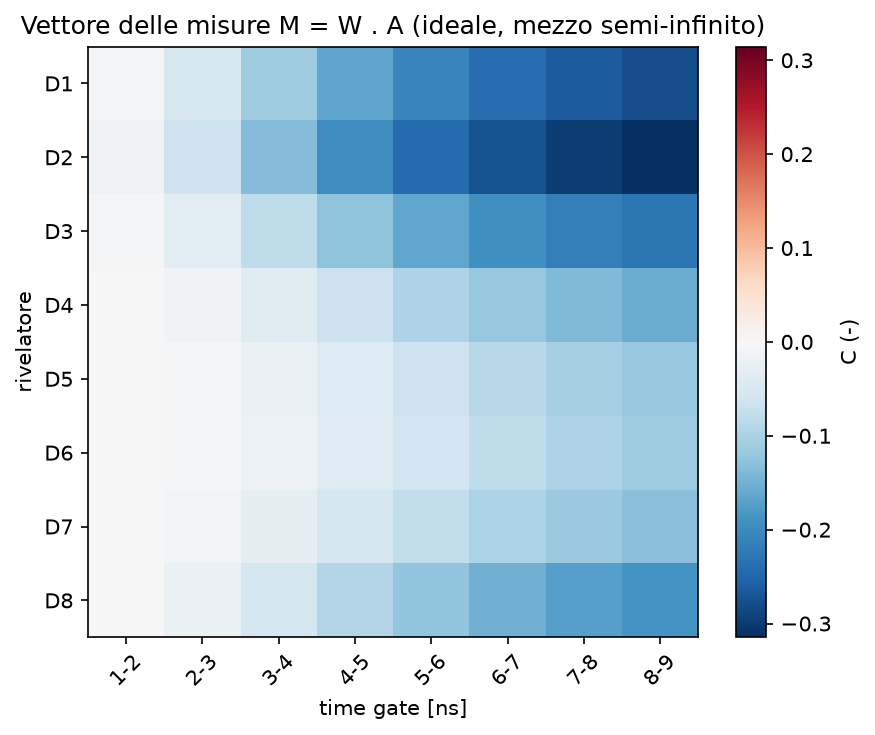

In [15]:
# STEP 4 - Vettore delle misure M = W . A (problema diretto, senza rumore)
M_ideal = (W @ A).reshape(N_det, N_gates)

print("VETTORE DELLE MISURE M = W . A (ideale, senza rumore)")
for d in range(N_det):
    print(f"  D{d+1}: " + " ".join(f"{val:+.4f}" for val in M_ideal[d, :]))

plt.figure(figsize=(6, 5))
im = plt.imshow(M_ideal, aspect='auto', cmap='RdBu_r',
                 vmin=-np.abs(M_ideal).max(), vmax=np.abs(M_ideal).max())
plt.yticks(range(N_det), [f'D{d+1}' for d in range(N_det)])
plt.xticks(range(N_gates), [f'{g[0]:.0f}-{g[1]:.0f}' for g in gates], rotation=45)
plt.xlabel('time gate [ns]'); plt.ylabel('rivelatore')
plt.title('Vettore delle misure M = W . A (ideale, mezzo semi-infinito)')
plt.colorbar(im, label='C (-)')
plt.tight_layout(); plt.show()


**Teoria.** Con $W$ (Step 3) e $A$ (Step 2) costruiti, il problema
**diretto** è un semplice prodotto matrice-vettore:

$$
M = W\cdot A, \qquad M\in\mathbb R^{N_{\rm det}\cdot N_{\rm gates}},\quad
A\in\mathbb R^{N_{\rm vox}}.
$$

$M[d,g]$ è il contrasto (adimensionale) previsto al rivelatore $d$, nel
time-gate $g$, per la distribuzione di assorbimento $A$. Non essendoci
alcuna sorgente di rumore aggiunta, $M$ è la misura "ideale": sarà
utilizzata, nella successiva fase di ricostruzione, come termine noto del
problema inverso — esattamente come, nel progetto originale, la matrice
$W$ viene poi decomposta in valori singolari (SVD) per invertire la
relazione $M=W\cdot A$ e risalire ad $A$ da $M$, un problema fortemente
sotto-determinato (come osservato allo Step 1) che richiederà
regolarizzazione.

**Logica di programmazione.** `.reshape(N_det, N_gates)` sfrutta il fatto
che le righe di `W` sono state riempite, allo Step 3, nell'ordine
`d*N_gates+g`: la stessa convenzione di indicizzazione va sempre rispettata
quando si passa da un indice "piatto" (comodo per l'algebra lineare, cioè
per il prodotto `W @ A`) a due indici "fisici" (rivelatore, gate) per
l'interpretazione e i grafici — un errore di convenzione qui produrrebbe
silenziosamente un vettore $M$ con le misure "mescolate" fra rivelatori e
gate diversi. La heatmap usa una colormap divergente (`RdBu_r`) centrata
sullo zero (`vmin=-max, vmax=+max`) per rendere immediatamente visibile il
segno del contrasto.

**Commento al grafico.** I rivelatori più vicini alla proiezione $(x_p,y_p)$
dell'inclusione ($x_p=15$, $y_p=10$, quindi principalmente D2 a $45^\circ$,
ma anche D1 e D3) mostrano il contrasto maggiore in valore assoluto, mentre
i rivelatori diametralmente opposti (D5, D6) ne vedono uno quasi nullo: è
esattamente il pattern di asimmetria azimutale atteso per un'inclusione
fuori asse — impossibile da osservare nel progetto originale, dove
l'unico rivelatore coincideva con la sorgente. Il segno negativo di $M$
riflette la fisica di un'inclusione **assorbente**: più fotoni vengono
assorbiti dal voxel perturbato, meno ne arrivano al rivelatore. Lungo i
gate, $|M|$ cresce lentamente con il tempo (i gate tardivi, più vicini alla
coda della DTOF, integrano un contributo maggiore dei fotoni che hanno
interagito con l'inclusione) — proprietà che sarà sfruttata per vincolare
meglio il problema inverso nella fase successiva di ricostruzione.


---
## Riepilogo e prossimi passi

Fino a questo punto il progetto ha riscritto, per le nuove ipotesi (mezzo
semi-infinito con condizione al contorno estrapolata, metodo delle
immagini, geometria a 8 rivelatori a raggiera non coincidenti con la
sorgente):

1. la **fluenza omogenea** e il **contrasto** analitico dovuto a una singola
   inclusione (Parte 1);
2. la **discretizzazione** dello spazio in voxel e del tempo in time-gate
   (Parte 2);
3. la **matrice di sensitività $W$** (Jacobiano del problema diretto
   linearizzato al prim'ordine di Born), il **vettore voxel $A$** e il
   **vettore delle misure ideali $M=W\cdot A$** (Parte 3).

Il problema diretto $M=W\cdot A$ è, per costruzione, fortemente
sotto-determinato ($N_{\rm det}\cdot N_{\rm gates} \ll N_{\rm vox}$): la
fase successiva (analoga alla Part 3 del progetto originale) affronterà
l'inversione — tipicamente tramite **decomposizione ai valori singolari
(SVD)** di $W$ e regolarizzazione — per ricostruire $A$ da $M$, con ed
eventualmente senza rumore aggiunto sulla misura.

**Effetto della riduzione di $z_{\rm ext}$ (64 → 32 mm) su questa analisi.**
Confrontando i numeri stampati in Parte 3 Step 1 con la versione a piena
profondità: dimezzando l'estensione verticale del dominio, $N_{\rm vox}$
dimezza a parità di `step`, mentre $N_{\rm det}\cdot N_{\rm gates}=64$ resta
invariato — il rapporto misure/incognite raddoppia, rendendo il problema
inverso meno drammaticamente sotto-determinato (pur restando tale). A valle
di ciò, l'intera matrice $W$ (Parte 3, Step 3) ha ora la metà delle colonne
(un voxel per colonna): le sezioni $\log_{10}|W|$ a $z=30$ mm restano
disponibili (30 mm $<$ 32 mm), ma la parte più profonda del dominio originale
(oltre 32 mm, dove la sensitività era già quasi nulla nella versione a piena
profondità, si veda il commento a Parte 3 Step 3) è stata **tagliata via**:
si sta cioè scartando prevalentemente la regione che contribuiva pochissimo
al segnale misurato, non informazione utile. È coerente con l'idea di
restringere il volume di ricostruzione alla sola regione fisicamente
raggiungibile dai fotoni in un tempo di gate ragionevole, un'assunzione
comune quando si conosce a priori l'ordine di grandezza della profondità
massima raggiungibile dalla geometria sorgente-rivelatore in uso.
